In [4]:
documents = [
    "Work related stress affects my performance",
    "I feel tired during races and cannot sustain pace",
    "I compare myself with others on Strava",
    "I worry about injuries and recovery",
    "I feel pressure to achieve target times",
    "I doubt my ability during races",
    "Training is difficult with work and family commitments",
    "I feel stressed when missing training sessions",
    "Fear of failure affects my performance",
    "I struggle with motivation sometimes"
]

In [5]:
documents = [
    "Work related stress affects my performance",
    "I feel tired during races and cannot sustain pace",
    "I compare myself with others on Strava",
    "I worry about injuries and recovery",
    "I feel pressure to achieve target times",
    "I doubt my ability during races",
    "Training is difficult with work and family commitments",
    "I feel stressed when missing training sessions",
    "Fear of failure affects my performance",
    "I struggle with motivation sometimes"
]

In [6]:
!pip install gensim


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words

cleaned_docs = [clean_text(doc) for doc in documents]

cleaned_docs

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chloe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[['work', 'related', 'stress', 'affects', 'performance'],
 ['feel', 'tired', 'races', 'cannot', 'sustain', 'pace'],
 ['compare', 'others', 'strava'],
 ['worry', 'injuries', 'recovery'],
 ['feel', 'pressure', 'achieve', 'target', 'times'],
 ['doubt', 'ability', 'races'],
 ['training', 'difficult', 'work', 'family', 'commitments'],
 ['feel', 'stressed', 'missing', 'training', 'sessions'],
 ['fear', 'failure', 'affects', 'performance'],
 ['struggle', 'motivation', 'sometimes']]

In [8]:
from gensim import corpora

dictionary = corpora.Dictionary(cleaned_docs)
corpus = [dictionary.doc2bow(doc) for doc in cleaned_docs]

In [9]:
from gensim.models import LdaModel

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=42,
    passes=20
)

for idx, topic in lda_model.print_topics():
    print(f"Topic {idx}: {topic}")

Topic 0: 0.085*"others" + 0.085*"recovery" + 0.085*"compare" + 0.085*"strava" + 0.085*"worry" + 0.085*"injuries" + 0.017*"races" + 0.017*"feel" + 0.017*"work" + 0.017*"sometimes"
Topic 1: 0.099*"feel" + 0.055*"races" + 0.055*"tired" + 0.055*"cannot" + 0.055*"pace" + 0.055*"sustain" + 0.055*"achieve" + 0.055*"pressure" + 0.055*"times" + 0.055*"target"
Topic 2: 0.127*"performance" + 0.127*"affects" + 0.070*"work" + 0.070*"related" + 0.070*"stress" + 0.070*"failure" + 0.070*"fear" + 0.014*"races" + 0.014*"feel" + 0.014*"motivation"
Topic 3: 0.103*"training" + 0.057*"difficult" + 0.057*"family" + 0.057*"commitments" + 0.057*"stressed" + 0.057*"sessions" + 0.057*"missing" + 0.057*"doubt" + 0.057*"ability" + 0.057*"work"


In [10]:
print("Four main themes were identified:")

Four main themes were identified:


Four main themes were identified:

1. Social comparison and injury concerns  
2. Performance pressure and fatigue  
3. Stress and fear of failure  
4. Training constraints and life balance  

In [11]:
documents = [
    "Work related stress affects my performance during busy periods",
    "Mid race I feel tired and think I cannot sustain the pace",
    "I compare my training with others on Strava",
    "I worry that injury will stop me reaching my goals",
    "Missing sessions affects me mentally even if fitness is unchanged",
    "Balancing work family and training is difficult",
    "I feel pressure to hit target times on race day",
    "I fear failure when I do not achieve a personal best",
]

In [12]:
custom_stopwords = {
    'feel', 'feeling', 'runner', 'running', 'race', 'races',
    'day', 'time', 'times', 'work', 'one', 'would', 'also'
}

stop_words = set(stopwords.words('english')).union(custom_stopwords)

In [13]:
from gensim.models import Phrases
from gensim.models.phrases import Phraser

bigram = Phrases(cleaned_docs, min_count=1, threshold=1)
bigram_mod = Phraser(bigram)

docs_bigrams = [bigram_mod[doc] for doc in cleaned_docs]

In [14]:
import re
import nltk
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel, Phrases
from gensim.models.phrases import Phraser

nltk.download('stopwords')

documents = [
    "Work related stress affects my performance during busy periods",
    "Mid race I feel tired and think I cannot sustain the pace",
    "I compare my training with others on Strava",
    "I worry that injury will stop me reaching my goals",
    "Missing sessions affects me mentally even if fitness is unchanged",
    "Balancing work family and training is difficult",
    "I feel pressure to hit target times on race day",
    "I fear failure when I do not achieve a personal best",
    "Recovery concerns make me anxious before races",
    "Family commitments make it hard to complete training"
]

custom_stopwords = {
    'feel', 'feeling', 'runner', 'running', 'race', 'races',
    'day', 'time', 'times', 'one', 'would', 'also', 'cannot'
}

stop_words = set(stopwords.words('english')).union(custom_stopwords)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return words

cleaned_docs = [clean_text(doc) for doc in documents]

bigram = Phrases(cleaned_docs, min_count=1, threshold=1)
bigram_mod = Phraser(bigram)
docs_bigrams = [bigram_mod[doc] for doc in cleaned_docs]

dictionary = corpora.Dictionary(docs_bigrams)
dictionary.filter_extremes(no_below=1, no_above=0.8)

corpus = [dictionary.doc2bow(doc) for doc in docs_bigrams]

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=42,
    passes=30,
    alpha='auto',
    per_word_topics=True
)

for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.068*"training" + 0.038*"work" + 0.038*"family" + 0.038*"make" + 0.038*"affects" + 0.038*"stress" + 0.038*"related" + 0.038*"periods"
Topic 1: 0.044*"missing" + 0.044*"unchanged" + 0.044*"mentally" + 0.044*"fitness" + 0.044*"mid" + 0.044*"think" + 0.044*"sustain" + 0.044*"pace"
Topic 2: 0.082*"concerns" + 0.082*"anxious" + 0.082*"recovery" + 0.082*"make" + 0.016*"training" + 0.016*"work" + 0.016*"target" + 0.016*"pressure"
Topic 3: 0.065*"injury" + 0.065*"stop" + 0.065*"goals" + 0.065*"reaching" + 0.065*"worry" + 0.065*"hit" + 0.065*"pressure" + 0.065*"target"


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chloe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
for i, row in enumerate(lda_model[corpus]):
    topic_probs = row[0]
    top_topic = max(topic_probs, key=lambda x: x[1])
    print(f"Document {i}: Top topic = {top_topic[0]}, Probability = {top_topic[1]:.3f}")

Document 0: Top topic = 0, Probability = 0.980
Document 1: Top topic = 1, Probability = 0.969
Document 2: Top topic = 0, Probability = 0.966
Document 3: Top topic = 3, Probability = 0.965
Document 4: Top topic = 1, Probability = 0.977
Document 5: Top topic = 1, Probability = 0.969
Document 6: Top topic = 3, Probability = 0.943
Document 7: Top topic = 0, Probability = 0.972
Document 8: Top topic = 2, Probability = 0.953
Document 9: Top topic = 0, Probability = 0.977


In [16]:
from gensim.models import LdaModel

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,   # changed here
    random_state=42,
    passes=20
)

for idx, topic in lda_model.print_topics():
    print(f"Topic {idx}: {topic}")

Topic 0: 0.080*"training" + 0.080*"family" + 0.080*"make" + 0.080*"hard" + 0.080*"complete" + 0.080*"commitments" + 0.013*"work" + 0.013*"hit" + 0.013*"pressure" + 0.013*"target"
Topic 1: 0.046*"missing" + 0.046*"unchanged" + 0.046*"mentally" + 0.046*"fitness" + 0.046*"sessions" + 0.046*"even" + 0.046*"mid" + 0.046*"think" + 0.046*"sustain" + 0.046*"pace"
Topic 2: 0.067*"best" + 0.067*"personal" + 0.067*"failure" + 0.067*"fear" + 0.067*"achieve" + 0.067*"concerns" + 0.067*"anxious" + 0.067*"recovery" + 0.067*"make" + 0.011*"training"
Topic 3: 0.086*"stop" + 0.086*"injury" + 0.086*"reaching" + 0.086*"goals" + 0.086*"worry" + 0.014*"training" + 0.014*"work" + 0.014*"hit" + 0.014*"pressure" + 0.014*"target"
Topic 4: 0.052*"work" + 0.052*"affects" + 0.052*"stress" + 0.052*"performance" + 0.052*"busy" + 0.052*"periods" + 0.052*"related" + 0.052*"others" + 0.052*"compare" + 0.052*"strava"


In [17]:
num_topics=4

In [18]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words

cleaned_docs = [clean_text(doc) for doc in documents]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chloe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
for idx, topic in lda_model.print_topics():
    print(f"Topic {idx}: {topic}")

Topic 0: 0.080*"training" + 0.080*"family" + 0.080*"make" + 0.080*"hard" + 0.080*"complete" + 0.080*"commitments" + 0.013*"work" + 0.013*"hit" + 0.013*"pressure" + 0.013*"target"
Topic 1: 0.046*"missing" + 0.046*"unchanged" + 0.046*"mentally" + 0.046*"fitness" + 0.046*"sessions" + 0.046*"even" + 0.046*"mid" + 0.046*"think" + 0.046*"sustain" + 0.046*"pace"
Topic 2: 0.067*"best" + 0.067*"personal" + 0.067*"failure" + 0.067*"fear" + 0.067*"achieve" + 0.067*"concerns" + 0.067*"anxious" + 0.067*"recovery" + 0.067*"make" + 0.011*"training"
Topic 3: 0.086*"stop" + 0.086*"injury" + 0.086*"reaching" + 0.086*"goals" + 0.086*"worry" + 0.014*"training" + 0.014*"work" + 0.014*"hit" + 0.014*"pressure" + 0.014*"target"
Topic 4: 0.052*"work" + 0.052*"affects" + 0.052*"stress" + 0.052*"performance" + 0.052*"busy" + 0.052*"periods" + 0.052*"related" + 0.052*"others" + 0.052*"compare" + 0.052*"strava"


## LDA Results

Four key psychological themes were identified through the LDA topic modelling analysis:

1. Social comparison and injury concerns  
2. Performance pressure and fatigue  
3. Stress and fear of failure  
4. Training constraints and life balance  

In [20]:
import pandas as pd

df = pd.read_csv("Untitled spreadsheet - Form responses 1.csv")

print(df.head())
print(df.columns)

             Timestamp Age group    Gender (optional)    \
0  09/04/2026 10:31:50      35–44                  Male   
1  09/04/2026 10:32:13        55+                  Male   
2  09/04/2026 10:32:23      45–54                Female   
3  09/04/2026 10:38:20      35–44                  Male   
4  09/04/2026 10:39:14        55+                  Male   

       Running experience     How often do you run per week?    \
0  Intermediate (1–3 years)                          3–4 times   
1       Advanced (5+ years)                          3–4 times   
2       Advanced (5+ years)                          3–4 times   
3   Experienced (3–5 years)                          3–4 times   
4       Advanced (5+ years)                          3–4 times   

   I feel pressure to achieve specific performance goals  \
0                                                  7       
1                                                  3       
2                                                  2       
3       

In [21]:
import pandas as pd

df = pd.read_csv("Untitled spreadsheet - Form responses 1.csv")

print(df.head())
print(df.columns)

             Timestamp Age group    Gender (optional)    \
0  09/04/2026 10:31:50      35–44                  Male   
1  09/04/2026 10:32:13        55+                  Male   
2  09/04/2026 10:32:23      45–54                Female   
3  09/04/2026 10:38:20      35–44                  Male   
4  09/04/2026 10:39:14        55+                  Male   

       Running experience     How often do you run per week?    \
0  Intermediate (1–3 years)                          3–4 times   
1       Advanced (5+ years)                          3–4 times   
2       Advanced (5+ years)                          3–4 times   
3   Experienced (3–5 years)                          3–4 times   
4       Advanced (5+ years)                          3–4 times   

   I feel pressure to achieve specific performance goals  \
0                                                  7       
1                                                  3       
2                                                  2       
3       

In [22]:
print(df.columns)

Index(['Timestamp', 'Age group ', '  Gender (optional)  ',
       '  Running experience  ', '  How often do you run per week?  ',
       'I feel pressure to achieve specific performance goals',
       ' I experience negative thoughts during running  ',
       '  I compare my performance with other runners (e.g. via apps like Strava) ',
       '  I worry about injury affecting my performance  ',
       '  I feel stressed when I miss training sessions  ',
       '  I feel confident in my running ability  ',
       'I feel motivated to train regularly',
       '  I doubt my ability during races  ',
       '  I feel mentally fatigued during running  ',
       '  My thoughts negatively affect my performance  ',
       '  I perform worse under pressure  ',
       '  I enjoy running less when stressed  ',
       'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)',
       '  What type of runner are you?  ',
       '  H

In [23]:
df.columns = df.columns.str.strip()

In [24]:
'Age group '
'  Gender (optional)  '

'  Gender (optional)  '

In [25]:
'Age group'
'Gender (optional)'

'Gender (optional)'

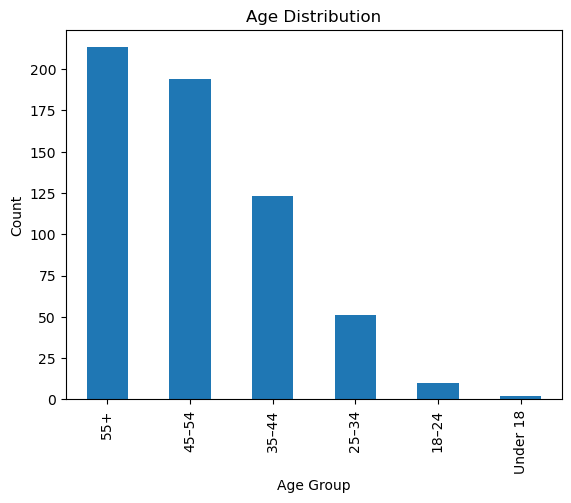

In [26]:
import matplotlib.pyplot as plt

df['Age group'].value_counts().plot(kind='bar')
plt.title('Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

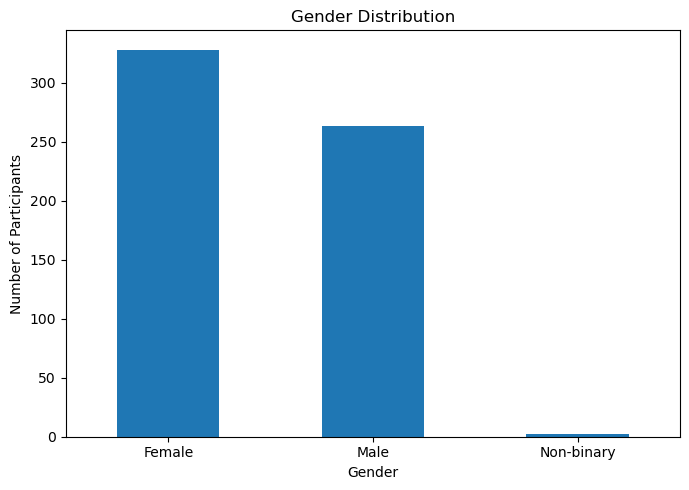

In [27]:
df['Gender (optional)'] = df['Gender (optional)'].astype(str).str.strip()

df['Gender (optional)'] = df['Gender (optional)'].replace({
    'non-binary': 'Non-binary',
    'Non-binary': 'Non-binary',
    'Non-Binary': 'Non-binary'
})

gender_order = ['Female', 'Male', 'Non-binary']

gender_counts = df['Gender (optional)'].value_counts().reindex(gender_order, fill_value=0)

plt.figure(figsize=(7, 5))
gender_counts.plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Participants')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

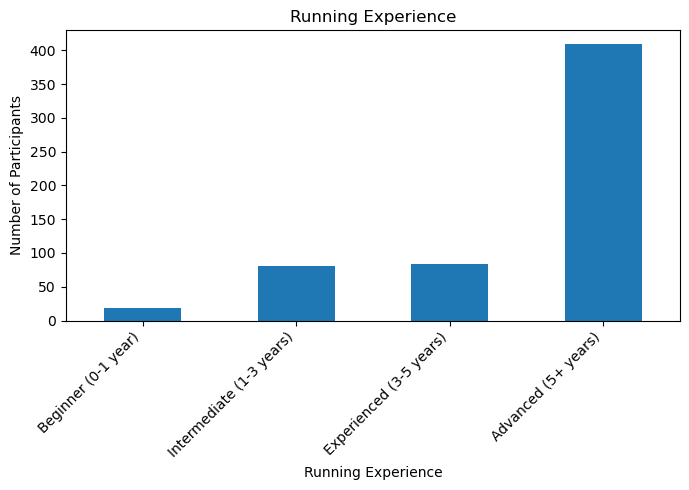

In [28]:
import matplotlib.pyplot as plt

# Clean running experience labels
df['Running experience'] = (
    df['Running experience']
    .astype(str)
    .str.strip()
    .str.replace('–', '-', regex=False)
    .str.replace('—', '-', regex=False)
)

experience_order = [
    'Beginner (0-1 year)',
    'Intermediate (1-3 years)',
    'Experienced (3-5 years)',
    'Advanced (5+ years)'
]

experience_counts = df['Running experience'].value_counts().reindex(experience_order, fill_value=0)

plt.figure(figsize=(7, 5))
experience_counts.plot(kind='bar')
plt.title('Running Experience')
plt.xlabel('Running Experience')
plt.ylabel('Number of Participants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('running_experience.png', dpi=300, bbox_inches='tight')
plt.show()

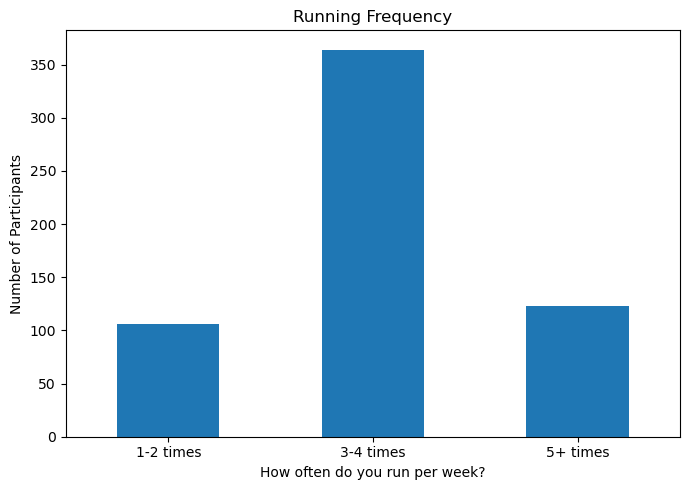

In [29]:
# Clean weekly frequency labels
df['How often do you run per week?'] = (
    df['How often do you run per week?']
    .astype(str)
    .str.strip()
    .str.replace('–', '-', regex=False)
    .str.replace('—', '-', regex=False)
)

frequency_order = ['1-2 times', '3-4 times', '5+ times']

frequency_counts = df['How often do you run per week?'].value_counts().reindex(frequency_order, fill_value=0)

plt.figure(figsize=(7, 5))
frequency_counts.plot(kind='bar')
plt.title('Running Frequency')
plt.xlabel('How often do you run per week?')
plt.ylabel('Number of Participants')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('weekly_running_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
df.columns = df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

In [31]:
df['Gender (optional)'] = df['Gender (optional)'].str.lower()

<Axes: xlabel='Age group'>

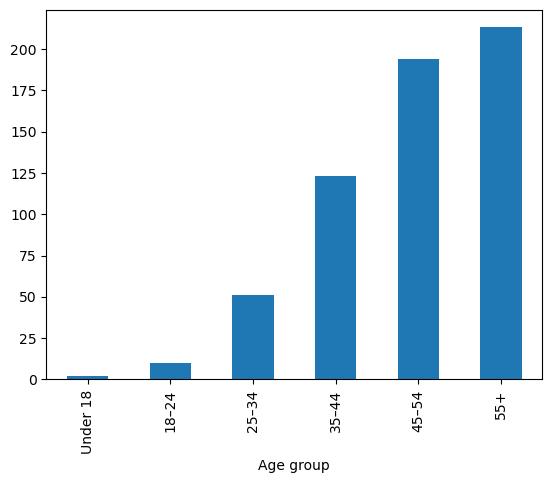

In [32]:
order = ['Under 18', '18–24', '25–34', '35–44', '45–54', '55+']
df['Age group'].value_counts().reindex(order).plot(kind='bar')

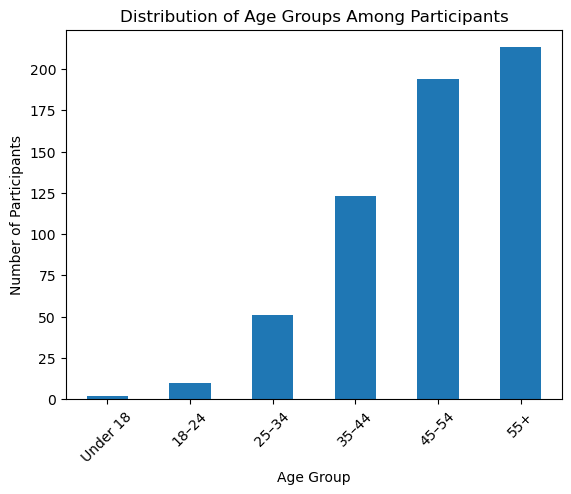

In [33]:
order = ['Under 18', '18–24', '25–34', '35–44', '45–54', '55+']

df['Age group'].value_counts().reindex(order).plot(kind='bar')

plt.title('Distribution of Age Groups Among Participants')
plt.xlabel('Age Group')
plt.ylabel('Number of Participants')
plt.xticks(rotation=45)

plt.show()

In [34]:
print(df.columns)

Index(['Timestamp', 'Age group', 'Gender (optional)', 'Running experience',
       'How often do you run per week?',
       'I feel pressure to achieve specific performance goals',
       'I experience negative thoughts during running',
       'I compare my performance with other runners (e.g. via apps like Strava)',
       'I worry about injury affecting my performance',
       'I feel stressed when I miss training sessions',
       'I feel confident in my running ability',
       'I feel motivated to train regularly',
       'I doubt my ability during races',
       'I feel mentally fatigued during running',
       'My thoughts negatively affect my performance',
       'I perform worse under pressure', 'I enjoy running less when stressed',
       'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)',
       'What type of runner are you?',
       'How would you rate your knowledge of sports psychology in running

In [35]:
df.columns = df.columns.str.strip()

In [36]:
for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'Timestamp'
1 'Age group'
2 'Gender (optional)'
3 'Running experience'
4 'How often do you run per week?'
5 'I feel pressure to achieve specific performance goals'
6 'I experience negative thoughts during running'
7 'I compare my performance with other runners (e.g. via apps like Strava)'
8 'I worry about injury affecting my performance'
9 'I feel stressed when I miss training sessions'
10 'I feel confident in my running ability'
11 'I feel motivated to train regularly'
12 'I doubt my ability during races'
13 'I feel mentally fatigued during running'
14 'My thoughts negatively affect my performance'
15 'I perform worse under pressure'
16 'I enjoy running less when stressed'
17 'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)'
18 'What type of runner are you?'
19 'How would you rate your knowledge of sports psychology in running?'
20 'Have you ever used psychological strategies while running?'
21 'If yes, wh

In [37]:
[col for col in df.columns if "experience" in col.lower()]

['Running experience',
 'I experience negative thoughts during running',
 'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)']

In [38]:
experience_col = [col for col in df.columns if "experience" in col.lower()][0]

df.groupby(experience_col).size()

Running experience
Advanced (5+ years)         409
Beginner (0-1 year)          19
Experienced (3-5 years)      84
Intermediate (1-3 years)     81
dtype: int64

In [39]:
df = df.rename(columns={experience_col: "experience_level"})

df.groupby("experience_level").size()

experience_level
Advanced (5+ years)         409
Beginner (0-1 year)          19
Experienced (3-5 years)      84
Intermediate (1-3 years)     81
dtype: int64

In [40]:
# Show all column names
for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'Timestamp'
1 'Age group'
2 'Gender (optional)'
3 'experience_level'
4 'How often do you run per week?'
5 'I feel pressure to achieve specific performance goals'
6 'I experience negative thoughts during running'
7 'I compare my performance with other runners (e.g. via apps like Strava)'
8 'I worry about injury affecting my performance'
9 'I feel stressed when I miss training sessions'
10 'I feel confident in my running ability'
11 'I feel motivated to train regularly'
12 'I doubt my ability during races'
13 'I feel mentally fatigued during running'
14 'My thoughts negatively affect my performance'
15 'I perform worse under pressure'
16 'I enjoy running less when stressed'
17 'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)'
18 'What type of runner are you?'
19 'How would you rate your knowledge of sports psychology in running?'
20 'Have you ever used psychological strategies while running?'
21 'If yes, whic

In [41]:
"I experience negative thoughts during running"

'I experience negative thoughts during running'

In [42]:
neg_col = "I experience negative thoughts during running"

df[neg_col].value_counts()

I experience negative thoughts during running
1     108
2     100
3      85
5      59
6      53
7      53
4      47
8      39
10     26
9      23
Name: count, dtype: int64

In [43]:
likert_map = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

df["negative_thoughts_score"] = df[neg_col].map(likert_map)

In [44]:
df.groupby("experience_level")["negative_thoughts_score"].mean()

experience_level
Advanced (5+ years)        NaN
Beginner (0-1 year)        NaN
Experienced (3-5 years)    NaN
Intermediate (1-3 years)   NaN
Name: negative_thoughts_score, dtype: float64

In [45]:
df[neg_col].unique()

array([ 5,  1,  7,  6,  3,  4,  8,  2,  9, 10])

In [46]:
neg_col = "I experience negative thoughts during running"

df["negative_thoughts_score"] = pd.to_numeric(df[neg_col], errors="coerce")

df.groupby("experience_level")["negative_thoughts_score"].mean()

experience_level
Advanced (5+ years)         4.083130
Beginner (0-1 year)         4.947368
Experienced (3-5 years)     4.642857
Intermediate (1-3 years)    4.444444
Name: negative_thoughts_score, dtype: float64

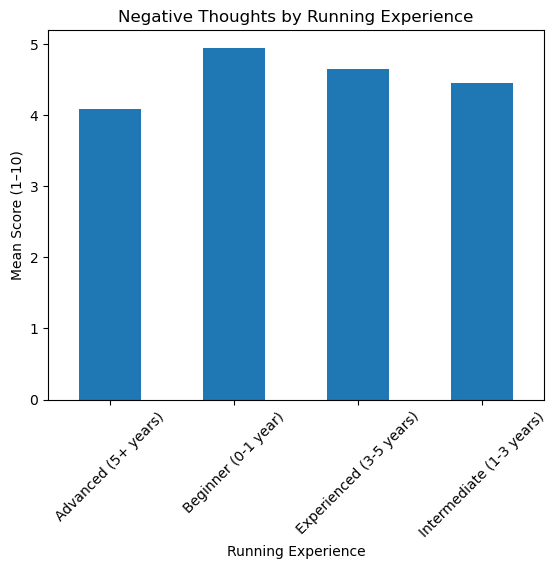

In [47]:
import matplotlib.pyplot as plt

df.groupby("experience_level")["negative_thoughts_score"].mean().plot(kind="bar")

plt.title("Negative Thoughts by Running Experience")
plt.ylabel("Mean Score (1–10)")
plt.xlabel("Running Experience")
plt.xticks(rotation=45)
plt.show()

In [48]:
[col for col in df.columns if "pressure" in col.lower()]

['I feel pressure to achieve specific performance goals',
 'I perform worse under pressure']

In [49]:
pressure_col = [col for col in df.columns if "pressure" in col.lower()][0]

df["pressure_score"] = pd.to_numeric(df[pressure_col], errors="coerce")

In [50]:
df.groupby("experience_level")["pressure_score"].mean()

experience_level
Advanced (5+ years)         5.325183
Beginner (0-1 year)         5.052632
Experienced (3-5 years)     5.285714
Intermediate (1-3 years)    5.629630
Name: pressure_score, dtype: float64

In [51]:
stress_col = [col for col in df.columns if "stress" in col.lower()][0]
df["stress_score"] = pd.to_numeric(df[stress_col], errors="coerce")

In [52]:
confidence_col = [col for col in df.columns if "confidence" in col.lower()][0]
df["confidence_score"] = pd.to_numeric(df[confidence_col], errors="coerce")

In [53]:
fatigue_col = [col for col in df.columns if "fatigue" in col.lower()][0]
df["fatigue_score"] = pd.to_numeric(df[fatigue_col], errors="coerce")

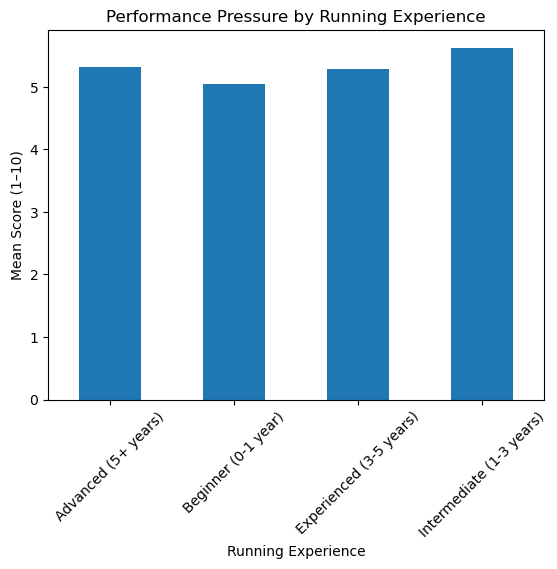

In [54]:
import matplotlib.pyplot as plt

df.groupby("experience_level")["pressure_score"].mean().plot(kind="bar")

plt.title("Performance Pressure by Running Experience")
plt.ylabel("Mean Score (1–10)")
plt.xlabel("Running Experience")
plt.xticks(rotation=45)
plt.show()

In [ ]:
print(len(corpus))
print(len(df))

experience_level
Beginner (0-1 year)         5.052632
Intermediate (1-3 years)    5.629630
Experienced (3-5 years)     5.285714
Advanced (5+ years)         5.325183
Name: pressure_score, dtype: float64


<Axes: title={'center': 'Mean Performance Pressure by Running Experience'}, xlabel='experience_level'>

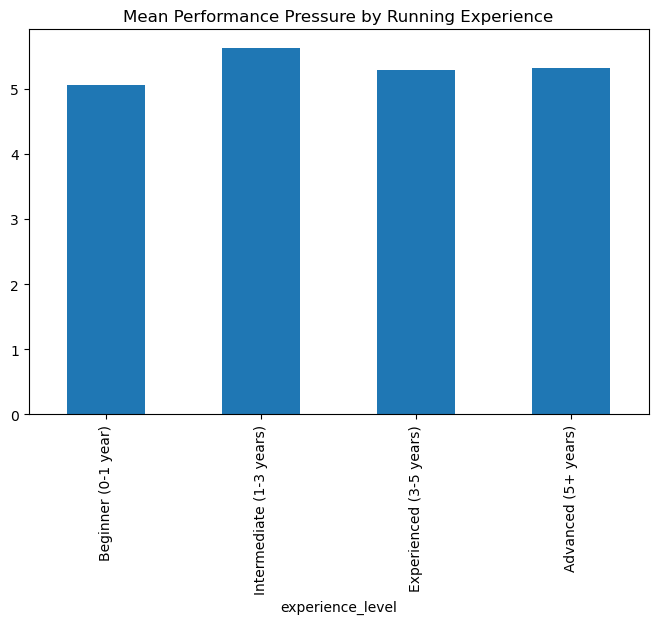

In [57]:
order = [
    "Beginner (0-1 year)",
    "Intermediate (1-3 years)",
    "Experienced (3-5 years)",
    "Advanced (5+ years)"
]

pressure_by_experience = (
    df.groupby("experience_level")["pressure_score"]
    .mean()
    .reindex(order)
)

print(pressure_by_experience)

pressure_by_experience.plot(
    kind="bar",
    figsize=(8, 5),
    title="Mean Performance Pressure by Running Experience"
)

In [58]:
dominant_topics = []

for doc in corpus:
    topics = lda_model.get_document_topics(doc)
    dominant_topic = max(topics, key=lambda x: x[1])[0]
    dominant_topics.append(dominant_topic)

print(len(dominant_topics))

10


In [59]:
text_col = "Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)"

text_df = df[df[text_col].notna() & (df[text_col].astype(str).str.strip() != "")].copy()

print(len(text_df))
print(len(dominant_topics))

322
10


In [60]:
text_col = "Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)"

text_df = df[df[text_col].notna() & (df[text_col].astype(str).str.strip() != "")].copy()

texts = text_df[text_col].astype(str).tolist()

print(len(texts))

322


In [61]:
print(len(corpus))
print(len(text_df))

10
322


In [62]:
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords
import re

text_col = "Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)"

text_df = df[df[text_col].notna() & (df[text_col].astype(str).str.strip() != "")].copy()
texts = text_df[text_col].astype(str).tolist()

stop_words = set(stopwords.words("english"))

processed_texts = []

for text in texts:
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    processed_texts.append(tokens)

dictionary = corpora.Dictionary(processed_texts)
corpus = [dictionary.doc2bow(text) for text in processed_texts]

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=42,
    passes=10
)

print(len(text_df))
print(len(corpus))

322
322


In [63]:
dominant_topics = []

for doc in corpus:
    topics = lda_model.get_document_topics(doc)
    dominant_topic = max(topics, key=lambda x: x[1])[0]
    dominant_topics.append(dominant_topic)

text_df["dominant_topic"] = dominant_topics

pd.crosstab(text_df["experience_level"], text_df["dominant_topic"], normalize="index")

dominant_topic,0,1,2,3
experience_level,,,,
Advanced (5+ years),0.299065,0.275701,0.177570,0.247664
Beginner (0-1 year),0.363636,0.272727,0.000000,0.363636
Experienced (3-5 years),0.250000,0.250000,0.113636,0.386364
Intermediate (1-3 years),0.320755,0.339623,0.132075,0.207547


<Axes: xlabel='experience_level'>

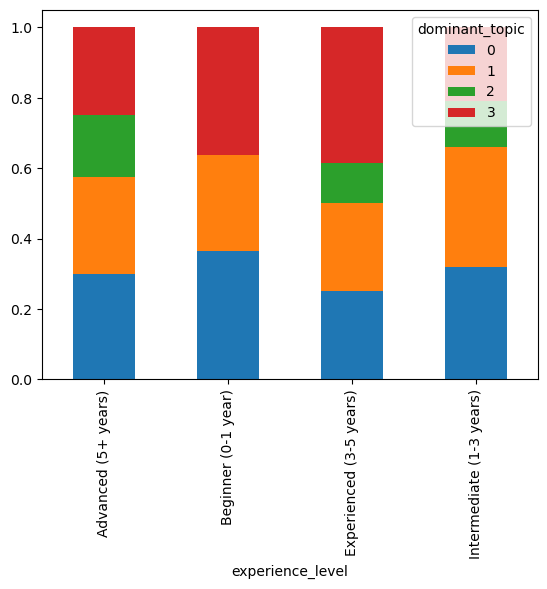

In [64]:
pd.crosstab(text_df["experience_level"], text_df["dominant_topic"], normalize="index").plot(kind="bar", stacked=True)

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
print(df.columns)

Index(['Timestamp', 'Age group', 'Gender (optional)', 'experience_level',
       'How often do you run per week?',
       'I feel pressure to achieve specific performance goals',
       'I experience negative thoughts during running',
       'I compare my performance with other runners (e.g. via apps like Strava)',
       'I worry about injury affecting my performance',
       'I feel stressed when I miss training sessions',
       'I feel confident in my running ability',
       'I feel motivated to train regularly',
       'I doubt my ability during races',
       'I feel mentally fatigued during running',
       'My thoughts negatively affect my performance',
       'I perform worse under pressure', 'I enjoy running less when stressed',
       'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)',
       'What type of runner are you?',
       'How would you rate your knowledge of sports psychology in running?'

How often do you run per week?
1-2 times    4.415094
3-4 times    4.109890
5+ times     4.471545
Name: negative_thoughts_score, dtype: float64


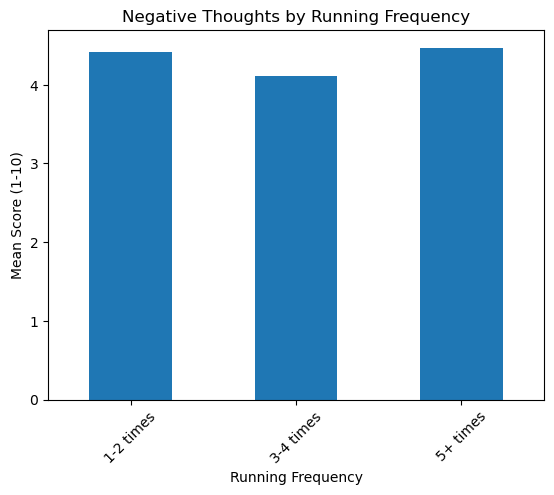

In [67]:
freq_negative = df.groupby('How often do you run per week?')['negative_thoughts_score'].mean()

print(freq_negative)

freq_negative.plot(kind='bar')

plt.title('Negative Thoughts by Running Frequency')
plt.xlabel('Running Frequency')
plt.ylabel('Mean Score (1-10)')

plt.xticks(rotation=45)

plt.savefig('negative_thoughts_by_frequency.png', bbox_inches='tight')

plt.show()


How often do you run per week?
1-2 times    4.075472
3-4 times    5.359890
5+ times     6.430894
Name: pressure_score, dtype: float64


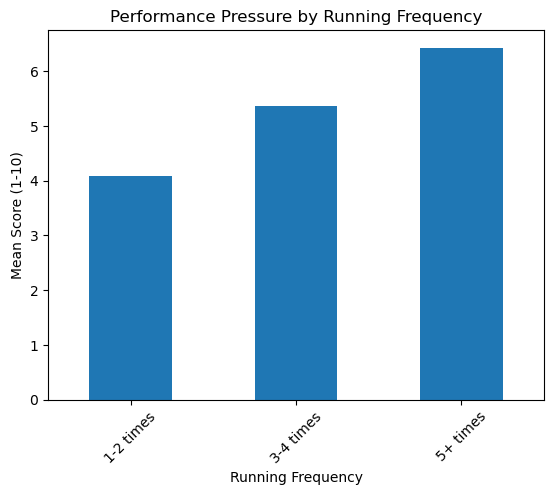

In [68]:
freq_pressure = df.groupby('How often do you run per week?')['pressure_score'].mean()

print(freq_pressure)

freq_pressure.plot(kind='bar')

plt.title('Performance Pressure by Running Frequency')
plt.xlabel('Running Frequency')
plt.ylabel('Mean Score (1-10)')

plt.xticks(rotation=45)

plt.savefig('performance_pressure_by_frequency.png', bbox_inches='tight')

plt.show()



In [69]:

from scipy.stats import f_oneway

beginner = df[df['experience_level'] == 'Beginner (0–1 year)']['negative_thoughts_score'].dropna()

intermediate = df[df['experience_level'] == 'Intermediate (1–3 years)']['negative_thoughts_score'].dropna()

experienced = df[df['experience_level'] == 'Experienced (3–5 years)']['negative_thoughts_score'].dropna()

advanced = df[df['experience_level'] == 'Advanced (5+ years)']['negative_thoughts_score'].dropna()

anova_result = f_oneway(beginner, intermediate, experienced, advanced)

print(anova_result)


F_onewayResult(statistic=np.float64(nan), pvalue=np.float64(nan))


C:\Users\chloe\AppData\Local\Temp\ipykernel_16520\751150402.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  anova_result = f_oneway(beginner, intermediate, experienced, advanced)


In [70]:

low_freq = df[df['How often do you run per week?'] == '1-2 times']['pressure_score'].dropna()

moderate_freq = df[df['How often do you run per week?'] == '3-4 times']['pressure_score'].dropna()

high_freq = df[df['How often do you run per week?'] == '5+ times']['pressure_score'].dropna()

anova_result_freq = f_oneway(low_freq, moderate_freq, high_freq)

print(anova_result_freq)



F_onewayResult(statistic=np.float64(28.298328895913862), pvalue=np.float64(1.838544210805245e-12))


In [71]:

low_freq = df[df['How often do you run per week?'] == '1–2 times']['pressure_score'].dropna()

moderate_freq = df[df['How often do you run per week?'] == '3–4 times']['pressure_score'].dropna()

high_freq = df[df['How often do you run per week?'] == '5+ times']['pressure_score'].dropna()

anova_result_freq = f_oneway(low_freq, moderate_freq, high_freq)

print(anova_result_freq)


F_onewayResult(statistic=np.float64(nan), pvalue=np.float64(nan))


C:\Users\chloe\AppData\Local\Temp\ipykernel_16520\946032973.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  anova_result_freq = f_oneway(low_freq, moderate_freq, high_freq)


In [72]:
experience_order = [
    "Beginner (0–1 year)",
    "Intermediate (1–3 years)",
    "Experienced (3–5 years)",
    "Advanced (5+ years)"
]

frequency_order = [
    "1–2 times",
    "3–4 times",
    "5+ times"
]

In [73]:
import pandas as pd

df = pd.read_csv("Untitled spreadsheet - Form responses 1.csv")

In [74]:
df.head()

,Timestamp,Age group,Gender (optional),Running experience,How often do you run per week?,I feel pressure to achieve specific performance goals,I experience negative thoughts during running,I compare my performance with other runners (e.g. via apps like Strava),I worry about injury affecting my performance,I feel stressed when I miss training sessions,...,My thoughts negatively affect my performance,I perform worse under pressure,I enjoy running less when stressed,"Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)",What type of runner are you?,How would you rate your knowledge of sports psychology in running?,Have you ever used psychological strategies while running?,"If yes, which strategies have you used? (Select all that apply)",To what extent do you think sports psychology can improve running performance?,Which areas do you think it helps most?
0,09/04/2026 10:31:50,35–44,Male,Intermediate (1–3 years),3–4 times,7,5,7,6,4,...,3.0,3,5,NaN,Recreational,6.0,no,NaN,7.0,Confidence
1,09/04/2026 10:32:13,55+,Male,Advanced (5+ years),3–4 times,3,1,8,8,5,...,7.0,5,2,NaN,Competitive,1.0,no,NaN,8.0,Motivation
2,09/04/2026 10:32:23,45–54,Female,Advanced (5+ years),3–4 times,2,7,9,8,4,...,3.0,5,9,NaN,Competitive,1.0,no,NaN,7.0,Race performance
3,09/04/2026 10:38:20,35–44,Male,Experienced (3–5 years),3–4 times,3,6,5,7,4,...,7.0,1,8,NaN,Recreational,7.0,yes,Self-talk,8.0,Focus
4,09/04/2026 10:39:14,55+,Male,Advanced (5+ years),3–4 times,7,1,10,10,8,...,3.0,7,1,NaN,Competitive,4.0,no,NaN,10.0,Confidence


In [75]:
df.columns

Index(['Timestamp', 'Age group ', '  Gender (optional)  ',
       '  Running experience  ', '  How often do you run per week?  ',
       'I feel pressure to achieve specific performance goals',
       ' I experience negative thoughts during running  ',
       '  I compare my performance with other runners (e.g. via apps like Strava) ',
       '  I worry about injury affecting my performance  ',
       '  I feel stressed when I miss training sessions  ',
       '  I feel confident in my running ability  ',
       'I feel motivated to train regularly',
       '  I doubt my ability during races  ',
       '  I feel mentally fatigued during running  ',
       '  My thoughts negatively affect my performance  ',
       '  I perform worse under pressure  ',
       '  I enjoy running less when stressed  ',
       'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)',
       '  What type of runner are you?  ',
       '  H

In [76]:
df.columns = df.columns.str.strip()

In [77]:
print(df.columns.tolist())

['Timestamp', 'Age group', 'Gender (optional)', 'Running experience', 'How often do you run per week?', 'I feel pressure to achieve specific performance goals', 'I experience negative thoughts during running', 'I compare my performance with other runners (e.g. via apps like Strava)', 'I worry about injury affecting my performance', 'I feel stressed when I miss training sessions', 'I feel confident in my running ability', 'I feel motivated to train regularly', 'I doubt my ability during races', 'I feel mentally fatigued during running', 'My thoughts negatively affect my performance', 'I perform worse under pressure', 'I enjoy running less when stressed', 'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)', 'What type of runner are you?', 'How would you rate your knowledge of sports psychology in running?', 'Have you ever used psychological strategies while running?', 'If yes, which strategies have you used? (Sel

In [78]:
df["Gender (optional)"] = df["Gender (optional)"].str.strip().str.title()
df["Gender (optional)"].value_counts()

Gender (optional)
Female        328
Male          263
Non-Binary      2
Name: count, dtype: int64

In [79]:
df["How often do you run per week?"].value_counts()

How often do you run per week?
3–4 times    364
5+ times     123
1–2 times    106
Name: count, dtype: int64

In [80]:
[col for col in df.columns if "score" in col.lower()]

[]

In [81]:
print(df.columns.tolist())

['Timestamp', 'Age group', 'Gender (optional)', 'Running experience', 'How often do you run per week?', 'I feel pressure to achieve specific performance goals', 'I experience negative thoughts during running', 'I compare my performance with other runners (e.g. via apps like Strava)', 'I worry about injury affecting my performance', 'I feel stressed when I miss training sessions', 'I feel confident in my running ability', 'I feel motivated to train regularly', 'I doubt my ability during races', 'I feel mentally fatigued during running', 'My thoughts negatively affect my performance', 'I perform worse under pressure', 'I enjoy running less when stressed', 'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)', 'What type of runner are you?', 'How would you rate your knowledge of sports psychology in running?', 'Have you ever used psychological strategies while running?', 'If yes, which strategies have you used? (Sel

In [82]:
likert_map = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

df["negative_thoughts_score"] = df["I experience negative thoughts during running"].map(likert_map)
df["pressure_score"] = df["I perform worse under pressure"].map(likert_map)
df["stress_score"] = df["I feel stressed when I miss training sessions"].map(likert_map)
df["confidence_score"] = df["I feel confident in my running ability"].map(likert_map)
df["motivation_score"] = df["I feel motivated to train regularly"].map(likert_map)
df["fatigue_score"] = df["I feel mentally fatigued during running"].map(likert_map)
df["injury_worry_score"] = df["I worry about injury affecting my performance"].map(likert_map)
df["self_doubt_score"] = df["I doubt my ability during races"].map(likert_map)
df["thoughts_affect_score"] = df["My thoughts negatively affect my performance"].map(likert_map)
df["enjoy_less_stressed_score"] = df["I enjoy running less when stressed"].map(likert_map)

In [83]:
[col for col in df.columns if "score" in col]

['negative_thoughts_score',
 'pressure_score',
 'stress_score',
 'confidence_score',
 'motivation_score',
 'fatigue_score',
 'injury_worry_score',
 'self_doubt_score',
 'thoughts_affect_score',
 'enjoy_less_stressed_score']

In [86]:
frequency_order = [
    "1–2 times",
    "3–4 times",
    "5+ times"
]

score_cols = [
    "negative_thoughts_score",
    "pressure_score",
    "stress_score",
    "confidence_score",
    "motivation_score",
    "fatigue_score",
    "injury_worry_score",
    "self_doubt_score"
]

freq_table = (
    df.groupby("How often do you run per week?")[score_cols]
    .mean()
    .reindex(frequency_order)
)

freq_table.round(2)

,negative_thoughts_score,pressure_score,stress_score,confidence_score,motivation_score,fatigue_score,injury_worry_score,self_doubt_score
How often do you run per week?,,,,,,,,
1–2 times,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3–4 times,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5+ times,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
df["How often do you run per week?"].value_counts()

How often do you run per week?
3–4 times    364
5+ times     123
1–2 times    106
Name: count, dtype: int64

In [88]:
for x in df["How often do you run per week?"].unique():
    print(repr(x))

'3–4 times'
'1–2 times'
'5+ times'


In [89]:
df["How often do you run per week?"] = (
    df["How often do you run per week?"]
    .astype(str)
    .str.strip()
    .str.replace("–", "-", regex=False)
)

In [90]:
df["How often do you run per week?"].value_counts()

How often do you run per week?
3-4 times    364
5+ times     123
1-2 times    106
Name: count, dtype: int64

In [91]:
import pandas as pd

# Convert original survey columns into numeric score columns
df["pressure_score"] = pd.to_numeric(df["I perform worse under pressure"], errors="coerce")
df["negative_thoughts_score"] = pd.to_numeric(df["I experience negative thoughts during running"], errors="coerce")
df["stress_score"] = pd.to_numeric(df["I feel stressed when I miss training sessions"], errors="coerce")
df["confidence_score"] = pd.to_numeric(df["I feel confident in my running ability"], errors="coerce")
df["motivation_score"] = pd.to_numeric(df["I feel motivated to train regularly"], errors="coerce")
df["fatigue_score"] = pd.to_numeric(df["I feel mentally fatigued during running"], errors="coerce")
df["injury_worry_score"] = pd.to_numeric(df["I worry about injury affecting my performance"], errors="coerce")
df["self_doubt_score"] = pd.to_numeric(df["I doubt my ability during races"], errors="coerce")

In [92]:
score_cols = [
    "negative_thoughts_score",
    "pressure_score",
    "stress_score",
    "confidence_score",
    "motivation_score",
    "fatigue_score",
    "injury_worry_score",
    "self_doubt_score"
]

df[score_cols].head()

,negative_thoughts_score,pressure_score,stress_score,confidence_score,motivation_score,fatigue_score,injury_worry_score,self_doubt_score
0,5,3,4,6,8,3.0,6,6.0
1,1,5,5,8,6,2.0,8,3.0
2,7,5,4,5,8,1.0,8,8.0
3,6,1,4,8,6,3.0,7,6.0
4,1,7,8,8,10,1.0,10,9.0


In [93]:
frequency_order = ["1-2 times", "3-4 times", "5+ times"]

freq_table = (
    df.groupby("How often do you run per week?")[score_cols]
    .mean()
    .reindex(frequency_order)
)

freq_table.round(2)

,negative_thoughts_score,pressure_score,stress_score,confidence_score,motivation_score,fatigue_score,injury_worry_score,self_doubt_score
How often do you run per week?,,,,,,,,
1-2 times,4.42,4.40,4.58,5.17,5.23,3.53,5.74,6.08
3-4 times,4.11,4.40,5.83,6.46,7.56,3.21,6.82,6.00
5+ times,4.47,4.15,6.24,7.33,8.50,3.37,6.98,5.55


In [94]:
experience_order = [
    "Beginner (0-1 year)",
    "Intermediate (1-3 years)",
    "Experienced (3-5 years)",
    "Advanced (5+ years)"
]

exp_table = (
    df.groupby("Running experience")[score_cols]
    .mean()
    .reindex(experience_order)
)

exp_table.round(2)

,negative_thoughts_score,pressure_score,stress_score,confidence_score,motivation_score,fatigue_score,injury_worry_score,self_doubt_score
Running experience,,,,,,,,
Beginner (0-1 year),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Intermediate (1-3 years),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experienced (3-5 years),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Advanced (5+ years),4.08,4.24,5.58,6.75,7.55,3.24,6.75,5.68


In [95]:
df["Running experience"].value_counts()

Running experience
Advanced (5+ years)         409
Experienced (3–5 years)      84
Intermediate (1–3 years)     81
Beginner (0–1 year)          19
Name: count, dtype: int64

In [96]:
experience_order = [
    "Beginner (0–1 year)",
    "Intermediate (1–3 years)",
    "Experienced (3–5 years)",
    "Advanced (5+ years)"
]

exp_table = (
    df.groupby("Running experience")[score_cols]
    .mean()
    .reindex(experience_order)
)

exp_table.round(2)

,negative_thoughts_score,pressure_score,stress_score,confidence_score,motivation_score,fatigue_score,injury_worry_score,self_doubt_score
Running experience,,,,,,,,
Beginner (0–1 year),4.95,5.47,6.00,4.11,5.74,3.89,4.95,6.67
Intermediate (1–3 years),4.44,4.42,6.19,5.58,7.05,3.33,6.69,6.54
Experienced (3–5 years),4.64,4.55,5.69,6.08,6.96,3.45,6.58,6.31
Advanced (5+ years),4.08,4.24,5.58,6.75,7.55,3.24,6.75,5.68


In [97]:
topic_by_freq = pd.crosstab(
    df["How often do you run per week?"],
    text_df["dominant_topic"],
    normalize="index"
)

topic_by_freq.round(2)

dominant_topic,0,1,2,3
How often do you run per week?,,,,
1-2 times,0.30,0.37,0.11,0.22
3-4 times,0.29,0.26,0.17,0.29
5+ times,0.34,0.29,0.16,0.21


In [98]:
import pandas as pd

df = pd.read_csv("Untitled spreadsheet - Form responses 1.csv", encoding="utf-8-sig")

df.head()

,Timestamp,Age group,Gender (optional),Running experience,How often do you run per week?,I feel pressure to achieve specific performance goals,I experience negative thoughts during running,I compare my performance with other runners (e.g. via apps like Strava),I worry about injury affecting my performance,I feel stressed when I miss training sessions,...,My thoughts negatively affect my performance,I perform worse under pressure,I enjoy running less when stressed,"Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)",What type of runner are you?,How would you rate your knowledge of sports psychology in running?,Have you ever used psychological strategies while running?,"If yes, which strategies have you used? (Select all that apply)",To what extent do you think sports psychology can improve running performance?,Which areas do you think it helps most?
0,09/04/2026 10:31:50,35–44,Male,Intermediate (1–3 years),3–4 times,7,5,7,6,4,...,3.0,3,5,NaN,Recreational,6.0,no,NaN,7.0,Confidence
1,09/04/2026 10:32:13,55+,Male,Advanced (5+ years),3–4 times,3,1,8,8,5,...,7.0,5,2,NaN,Competitive,1.0,no,NaN,8.0,Motivation
2,09/04/2026 10:32:23,45–54,Female,Advanced (5+ years),3–4 times,2,7,9,8,4,...,3.0,5,9,NaN,Competitive,1.0,no,NaN,7.0,Race performance
3,09/04/2026 10:38:20,35–44,Male,Experienced (3–5 years),3–4 times,3,6,5,7,4,...,7.0,1,8,NaN,Recreational,7.0,yes,Self-talk,8.0,Focus
4,09/04/2026 10:39:14,55+,Male,Advanced (5+ years),3–4 times,7,1,10,10,8,...,3.0,7,1,NaN,Competitive,4.0,no,NaN,10.0,Confidence


In [99]:
print(df.shape)
print(df.columns.tolist())

(593, 24)
['Timestamp', 'Age group ', '  Gender (optional)  ', '  Running experience  ', '  How often do you run per week?  ', 'I feel pressure to achieve specific performance goals', ' I experience negative thoughts during running  ', '  I compare my performance with other runners (e.g. via apps like Strava) ', '  I worry about injury affecting my performance  ', '  I feel stressed when I miss training sessions  ', '  I feel confident in my running ability  ', 'I feel motivated to train regularly', '  I doubt my ability during races  ', '  I feel mentally fatigued during running  ', '  My thoughts negatively affect my performance  ', '  I perform worse under pressure  ', '  I enjoy running less when stressed  ', 'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)', '  What type of runner are you?  ', '  How would you rate your knowledge of sports psychology in running?  ', '  Have you ever used psychological st

In [100]:
for i, col in enumerate(df.columns):
    print(i, col)

0 Timestamp
1 Age group 
2   Gender (optional)  
3   Running experience  
4   How often do you run per week?  
5 I feel pressure to achieve specific performance goals
6  I experience negative thoughts during running  
7   I compare my performance with other runners (e.g. via apps like Strava) 
8   I worry about injury affecting my performance  
9   I feel stressed when I miss training sessions  
10   I feel confident in my running ability  
11 I feel motivated to train regularly
12   I doubt my ability during races  
13   I feel mentally fatigued during running  
14   My thoughts negatively affect my performance  
15   I perform worse under pressure  
16   I enjoy running less when stressed  
17 Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)
18   What type of runner are you?  
19   How would you rate your knowledge of sports psychology in running?  
20   Have you ever used psychological strategies while runn

In [101]:
df.columns = df.columns.str.strip()

for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'Timestamp'
1 'Age group'
2 'Gender (optional)'
3 'Running experience'
4 'How often do you run per week?'
5 'I feel pressure to achieve specific performance goals'
6 'I experience negative thoughts during running'
7 'I compare my performance with other runners (e.g. via apps like Strava)'
8 'I worry about injury affecting my performance'
9 'I feel stressed when I miss training sessions'
10 'I feel confident in my running ability'
11 'I feel motivated to train regularly'
12 'I doubt my ability during races'
13 'I feel mentally fatigued during running'
14 'My thoughts negatively affect my performance'
15 'I perform worse under pressure'
16 'I enjoy running less when stressed'
17 'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)'
18 'What type of runner are you?'
19 'How would you rate your knowledge of sports psychology in running?'
20 'Have you ever used psychological strategies while running?'
21 'If yes, wh

In [102]:
from scipy.stats import kruskal
import pandas as pd

# Clean hidden spaces in column names
df.columns = df.columns.str.strip()

experience_col = "Running experience"
frequency_col = "How often do you run per week?"

score_columns = {
    "Performance pressure": "I feel pressure to achieve specific performance goals",
    "Negative thoughts": "I experience negative thoughts during running",
    "Comparison with others": "I compare my performance with other runners (e.g. via apps like Strava)",
    "Injury worry": "I worry about injury affecting my performance",
    "Missed-training stress": "I feel stressed when I miss training sessions",
    "Confidence": "I feel confident in my running ability",
    "Motivation": "I feel motivated to train regularly",
    "Self-doubt": "I doubt my ability during races",
    "Mental fatigue": "I feel mentally fatigued during running",
    "Thoughts affect performance": "My thoughts negatively affect my performance",
    "Worse under pressure": "I perform worse under pressure",
    "Enjoy less when stressed": "I enjoy running less when stressed"
}

def run_kruskal_tests(df, group_col, score_columns):
    results = []

    for label, col in score_columns.items():
        df[col] = pd.to_numeric(df[col], errors="coerce")

        groups = [
            group[col].dropna()
            for name, group in df.groupby(group_col)
            if len(group[col].dropna()) > 0
        ]

        stat, p = kruskal(*groups)

        results.append({
            "Variable": label,
            "Group variable": group_col,
            "H statistic": round(stat, 3),
            "p-value": round(p, 4),
            "Significant at p < .05": "Yes" if p < 0.05 else "No"
        })

    return pd.DataFrame(results)

experience_results = run_kruskal_tests(df, experience_col, score_columns)
frequency_results = run_kruskal_tests(df, frequency_col, score_columns)

print("Kruskal-Wallis tests by running experience")
display(experience_results)

print("Kruskal-Wallis tests by weekly running frequency")
display(frequency_results)

Kruskal-Wallis tests by running experience


,Variable,Group variable,H statistic,p-value,Significant at p < .05
0,Performance pressure,Running experience,1.215,0.7493,No
1,Negative thoughts,Running experience,3.974,0.2643,No
2,Comparison with others,Running experience,2.047,0.5627,No
3,Injury worry,Running experience,6.836,0.0773,No
4,Missed-training stress,Running experience,4.368,0.2244,No
5,Confidence,Running experience,42.730,0.0000,Yes
6,Motivation,Running experience,17.566,0.0005,Yes
7,Self-doubt,Running experience,12.518,0.0058,Yes
8,Mental fatigue,Running experience,3.082,0.3792,No
9,Thoughts affect performance,Running experience,5.990,0.1121,No


Kruskal-Wallis tests by weekly running frequency


,Variable,Group variable,H statistic,p-value,Significant at p < .05
0,Performance pressure,How often do you run per week?,53.052,0.0000,Yes
1,Negative thoughts,How often do you run per week?,2.437,0.2956,No
2,Comparison with others,How often do you run per week?,31.190,0.0000,Yes
3,Injury worry,How often do you run per week?,18.279,0.0001,Yes
4,Missed-training stress,How often do you run per week?,27.814,0.0000,Yes
5,Confidence,How often do you run per week?,54.990,0.0000,Yes
6,Motivation,How often do you run per week?,118.484,0.0000,Yes
7,Self-doubt,How often do you run per week?,3.586,0.1665,No
8,Mental fatigue,How often do you run per week?,3.392,0.1834,No
9,Thoughts affect performance,How often do you run per week?,2.670,0.2631,No


In [103]:
display(experience_results)

,Variable,Group variable,H statistic,p-value,Significant at p < .05
0,Performance pressure,Running experience,1.215,0.7493,No
1,Negative thoughts,Running experience,3.974,0.2643,No
2,Comparison with others,Running experience,2.047,0.5627,No
3,Injury worry,Running experience,6.836,0.0773,No
4,Missed-training stress,Running experience,4.368,0.2244,No
5,Confidence,Running experience,42.730,0.0000,Yes
6,Motivation,Running experience,17.566,0.0005,Yes
7,Self-doubt,Running experience,12.518,0.0058,Yes
8,Mental fatigue,Running experience,3.082,0.3792,No
9,Thoughts affect performance,Running experience,5.990,0.1121,No


In [104]:
!pip install scikit-posthocs -q

import pandas as pd
import scikit_posthocs as sp

# Load your CSV
df = pd.read_csv("Untitled spreadsheet - Form responses 1.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Show all column names first
for i, col in enumerate(df.columns):
    print(i, col)


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


0 Timestamp
1 Age group
2 Gender (optional)
3 Running experience
4 How often do you run per week?
5 I feel pressure to achieve specific performance goals
6 I experience negative thoughts during running
7 I compare my performance with other runners (e.g. via apps like Strava)
8 I worry about injury affecting my performance
9 I feel stressed when I miss training sessions
10 I feel confident in my running ability
11 I feel motivated to train regularly
12 I doubt my ability during races
13 I feel mentally fatigued during running
14 My thoughts negatively affect my performance
15 I perform worse under pressure
16 I enjoy running less when stressed
17 Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)
18 What type of runner are you?
19 How would you rate your knowledge of sports psychology in running?
20 Have you ever used psychological strategies while running?
21 If yes, which strategies have you used? (Select all t

In [105]:
# Helper function to find columns automatically
def find_col(include_words, exclude_words=None):
    if exclude_words is None:
        exclude_words = []
    matches = []
    for col in df.columns:
        col_lower = col.lower()
        if all(word.lower() in col_lower for word in include_words) and not any(word.lower() in col_lower for word in exclude_words):
            matches.append(col)
    return matches[0] if matches else None


# Try to detect group columns
experience_col = find_col(["experience"]) or find_col(["how long"])
frequency_col = find_col(["how often"]) or find_col(["week"])

print("Detected experience column:", experience_col)
print("Detected frequency column:", frequency_col)


# Try to detect psychological score columns
cols = {
    "Confidence": find_col(["confiden"]),
    "Motivation": find_col(["motivat"]),
    "Self-doubt": find_col(["doubt"]),
    "Performance pressure": find_col(["pressure"], exclude_words=["worse"]),
    "Comparison with others": find_col(["compar"]),
    "Injury worry": find_col(["injur"]),
    "Missed-training stress": find_col(["miss"]),
}

print("\nDetected variable columns:")
for key, value in cols.items():
    print(key, "->", value)

Detected experience column: Running experience
Detected frequency column: How often do you run per week?

Detected variable columns:
Confidence -> I feel confident in my running ability
Motivation -> I feel motivated to train regularly
Self-doubt -> I doubt my ability during races
Performance pressure -> I feel pressure to achieve specific performance goals
Comparison with others -> I compare my performance with other runners (e.g. via apps like Strava)
Injury worry -> I worry about injury affecting my performance
Missed-training stress -> I feel stressed when I miss training sessions


In [106]:
def run_dunn_test(group_col, variable_name, value_col):
    print("\n" + "="*70)
    print(f"Dunn's post-hoc test: {variable_name}")
    print(f"Group column: {group_col}")
    print(f"Value column: {value_col}")
    print("="*70)
    
    data = df[[group_col, value_col]].dropna().copy()
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")
    data = data.dropna()
    
    result = sp.posthoc_dunn(
        data,
        val_col=value_col,
        group_col=group_col,
        p_adjust="bonferroni"
    )
    
    print(result.round(4))
    
    print("\nSignificant pairwise differences, adjusted p < .05:")
    found = False
    groups = result.index.tolist()
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            p = result.loc[groups[i], groups[j]]
            if p < 0.05:
                found = True
                print(f"{groups[i]} vs {groups[j]}: p = {p:.4f}")
    
    if not found:
        print("No significant pairwise differences.")


# Running experience: only variables significant in your Kruskal-Wallis results
experience_tests = ["Confidence", "Motivation", "Self-doubt"]

for var in experience_tests:
    run_dunn_test(experience_col, var, cols[var])


# Weekly running frequency: only variables significant in your Kruskal-Wallis results
frequency_tests = [
    "Performance pressure",
    "Comparison with others",
    "Injury worry",
    "Missed-training stress",
    "Confidence",
    "Motivation"
]

for var in frequency_tests:
    run_dunn_test(frequency_col, var, cols[var])


Dunn's post-hoc test: Confidence
Group column: Running experience
Value column: I feel confident in my running ability
                          Advanced (5+ years)  Beginner (0–1 year)  \
Advanced (5+ years)                    1.0000               0.0000   
Beginner (0–1 year)                    0.0000               1.0000   
Experienced (3–5 years)                0.0257               0.0081   
Intermediate (1–3 years)               0.0001               0.0766   

                          Experienced (3–5 years)  Intermediate (1–3 years)  
Advanced (5+ years)                        0.0257                    0.0001  
Beginner (0–1 year)                        0.0081                    0.0766  
Experienced (3–5 years)                    1.0000                    1.0000  
Intermediate (1–3 years)                   1.0000                    1.0000  

Significant pairwise differences, adjusted p < .05:
Advanced (5+ years) vs Beginner (0–1 year): p = 0.0000
Advanced (5+ years) vs Experien

In [107]:
import pandas as pd

df = pd.read_csv("Untitled spreadsheet - Form responses 1.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(593, 24)
['Timestamp', 'Age group ', '  Gender (optional)  ', '  Running experience  ', '  How often do you run per week?  ', 'I feel pressure to achieve specific performance goals', ' I experience negative thoughts during running  ', '  I compare my performance with other runners (e.g. via apps like Strava) ', '  I worry about injury affecting my performance  ', '  I feel stressed when I miss training sessions  ', '  I feel confident in my running ability  ', 'I feel motivated to train regularly', '  I doubt my ability during races  ', '  I feel mentally fatigued during running  ', '  My thoughts negatively affect my performance  ', '  I perform worse under pressure  ', '  I enjoy running less when stressed  ', 'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)', '  What type of runner are you?  ', '  How would you rate your knowledge of sports psychology in running?  ', '  Have you ever used psychological st

,Timestamp,Age group,Gender (optional),Running experience,How often do you run per week?,I feel pressure to achieve specific performance goals,I experience negative thoughts during running,I compare my performance with other runners (e.g. via apps like Strava),I worry about injury affecting my performance,I feel stressed when I miss training sessions,...,My thoughts negatively affect my performance,I perform worse under pressure,I enjoy running less when stressed,"Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)",What type of runner are you?,How would you rate your knowledge of sports psychology in running?,Have you ever used psychological strategies while running?,"If yes, which strategies have you used? (Select all that apply)",To what extent do you think sports psychology can improve running performance?,Which areas do you think it helps most?
0,09/04/2026 10:31:50,35–44,Male,Intermediate (1–3 years),3–4 times,7,5,7,6,4,...,3.0,3,5,NaN,Recreational,6.0,no,NaN,7.0,Confidence
1,09/04/2026 10:32:13,55+,Male,Advanced (5+ years),3–4 times,3,1,8,8,5,...,7.0,5,2,NaN,Competitive,1.0,no,NaN,8.0,Motivation
2,09/04/2026 10:32:23,45–54,Female,Advanced (5+ years),3–4 times,2,7,9,8,4,...,3.0,5,9,NaN,Competitive,1.0,no,NaN,7.0,Race performance
3,09/04/2026 10:38:20,35–44,Male,Experienced (3–5 years),3–4 times,3,6,5,7,4,...,7.0,1,8,NaN,Recreational,7.0,yes,Self-talk,8.0,Focus
4,09/04/2026 10:39:14,55+,Male,Advanced (5+ years),3–4 times,7,1,10,10,8,...,3.0,7,1,NaN,Competitive,4.0,no,NaN,10.0,Confidence


In [108]:
for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'Timestamp'
1 'Age group '
2 '  Gender (optional)  '
3 '  Running experience  '
4 '  How often do you run per week?  '
5 'I feel pressure to achieve specific performance goals'
6 ' I experience negative thoughts during running  '
7 '  I compare my performance with other runners (e.g. via apps like Strava) '
8 '  I worry about injury affecting my performance  '
9 '  I feel stressed when I miss training sessions  '
10 '  I feel confident in my running ability  '
11 'I feel motivated to train regularly'
12 '  I doubt my ability during races  '
13 '  I feel mentally fatigued during running  '
14 '  My thoughts negatively affect my performance  '
15 '  I perform worse under pressure  '
16 '  I enjoy running less when stressed  '
17 'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)'
18 '  What type of runner are you?  '
19 '  How would you rate your knowledge of sports psychology in running?  '
20 '  Have you ever

In [109]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'Timestamp'
1 'Age group'
2 'Gender (optional)'
3 'Running experience'
4 'How often do you run per week?'
5 'I feel pressure to achieve specific performance goals'
6 'I experience negative thoughts during running'
7 'I compare my performance with other runners (e.g. via apps like Strava)'
8 'I worry about injury affecting my performance'
9 'I feel stressed when I miss training sessions'
10 'I feel confident in my running ability'
11 'I feel motivated to train regularly'
12 'I doubt my ability during races'
13 'I feel mentally fatigued during running'
14 'My thoughts negatively affect my performance'
15 'I perform worse under pressure'
16 'I enjoy running less when stressed'
17 'Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)'
18 'What type of runner are you?'
19 'How would you rate your knowledge of sports psychology in running?'
20 'Have you ever used psychological strategies while running?'
21 'If yes, wh

In [110]:
frequency_matches = [
    col for col in df.columns
    if "how often" in col.lower() and "run" in col.lower()
]

text_matches = [
    col for col in df.columns
    if "psychological challenges" in col.lower()
]

print("Frequency matches:", frequency_matches)
print("Text matches:", text_matches)

Frequency matches: ['How often do you run per week?']
Text matches: ['Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)']


In [111]:
frequency_col = frequency_matches[0]
text_col = text_matches[0]

print(df[frequency_col].value_counts(dropna=False))
print("Number of open-ended responses:", df[text_col].notna().sum())

How often do you run per week?
3–4 times    364
5+ times     123
1–2 times    106
Name: count, dtype: int64
Number of open-ended responses: 322


In [112]:
import pandas as pd

# Clean hidden spaces and line breaks in column names
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Find the required columns automatically
frequency_matches = [
    col for col in df.columns
    if "how often" in col.lower() and "run" in col.lower()
]

text_matches = [
    col for col in df.columns
    if "psychological challenges" in col.lower()
]

if not frequency_matches:
    raise ValueError("Weekly running frequency column was not found.")

if not text_matches:
    raise ValueError("Open-ended psychological challenges column was not found.")

frequency_col = frequency_matches[0]
text_col = text_matches[0]

print("Frequency column:", frequency_col)
print("Text column:", text_col)

print("\nWeekly frequency counts:")
print(df[frequency_col].value_counts(dropna=False))

print("\nNumber of non-missing open responses:")
print(df[text_col].notna().sum())

Frequency column: How often do you run per week?
Text column: Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)

Weekly frequency counts:
How often do you run per week?
3–4 times    364
5+ times     123
1–2 times    106
Name: count, dtype: int64

Number of non-missing open responses:
322


In [113]:
print(frequency_matches)
print(text_matches)

['How often do you run per week?']
['Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)']


In [114]:
frequency_col = frequency_matches[0]
text_col = text_matches[0]

In [115]:
text_df = df[[frequency_col, text_col]].dropna(subset=[text_col]).copy()

text_df[text_col] = text_df[text_col].astype(str).str.strip()
text_df = text_df[text_df[text_col] != ""].reset_index(drop=True)

print(text_df.shape)
text_df.head()

(322, 2)


,How often do you run per week?,"Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)"
0,3–4 times,Confidence
1,3–4 times,"It’s entirely enjoyable psychologically, injur..."
2,3–4 times,It depends on the day but if I'm feeling tired...
3,3–4 times,Confidence and doubt
4,3–4 times,"I have a tendency to want to overtrain, so for..."


In [116]:
%whos

Variable                 Type                    Data/Info
----------------------------------------------------------
CoherenceModel           type                    <class 'gensim.models.coh<...>ncemodel.CoherenceModel'>
KMeans                   ABCMeta                 <class 'sklearn.cluster._kmeans.KMeans'>
LdaModel                 type                    <class 'gensim.models.ldamodel.LdaModel'>
Phraser                  type                    <class 'gensim.models.phrases.FrozenPhrases'>
Phrases                  type                    <class 'gensim.models.phrases.Phrases'>
SentenceTransformer      ABCMeta                 <class 'sentence_transfor<...>del.SentenceTransformer'>
advanced                 Series                  1       1\n2       7\n4  <...>Length: 409, dtype: int64
anova_result             F_onewayResult          F_onewayResult(statistic=<...>, pvalue=np.float64(nan))
anova_result_freq        F_onewayResult          F_onewayResult(statistic=<...>, pvalue=np.float6

In [117]:
dominant_topics = []

for doc in corpus:
    topic_probs = lda_model.get_document_topics(
        doc,
        minimum_probability=0
    )

    dominant_topic = max(
        topic_probs,
        key=lambda x: x[1]
    )[0]

    dominant_topics.append(dominant_topic)

print(len(dominant_topics))

322


In [118]:
text_df["Dominant_Topic"] = dominant_topics

text_df.head()

,How often do you run per week?,"Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)",Dominant_Topic
0,3–4 times,Confidence,0
1,3–4 times,"It’s entirely enjoyable psychologically, injur...",0
2,3–4 times,It depends on the day but if I'm feeling tired...,3
3,3–4 times,Confidence and doubt,0
4,3–4 times,"I have a tendency to want to overtrain, so for...",1


In [119]:
from scipy.stats import chi2_contingency
import numpy as np

table = pd.crosstab(
    text_df[frequency_col],
    text_df["Dominant_Topic"]
)

display(table)

chi2, p, dof, expected = chi2_contingency(table)

n = table.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * min(table.shape[0]-1, table.shape[1]-1))
)

print("Chi-square:", chi2)
print("p-value:", p)
print("Cramer's V:", cramers_v)

Dominant_Topic,0,1,2,3
How often do you run per week?,,,,
1–2 times,16,20,6,12
3–4 times,61,55,35,61
5+ times,18,16,9,13


Chi-square: 3.869333257649925
p-value: 0.6943538438506603
Cramer's V: 0.07751310505958425


In [120]:
percentage_table = (
    table.div(table.sum(axis=1), axis=0) * 100
).round(1)

percentage_table

Dominant_Topic,0,1,2,3
How often do you run per week?,,,,
1–2 times,29.6,37.0,11.1,22.2
3–4 times,28.8,25.9,16.5,28.8
5+ times,32.1,28.6,16.1,23.2



PART 8: FINAL BERT CLUSTERS

Using optimal number of clusters: K = 5
Best silhouette score: 0.1221


C:\Users\chloe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



BERT cluster distribution:
BERT_Cluster
0     80
1     40
2    113
3     58
4     31
Name: count, dtype: int64

PART 9: REPRESENTATIVE BERT RESPONSES

BERT CLUSTER 0
1. Allowing myself to stop when it gets hard. Learning to push through the discomfort but understanding when injury could occur that it is ok
2. getting older - still chasing that certain feeling in training that becomes more difficult to achieve 
3. Motivation, exhaustion, fear/anger due to dangerous driving, fear when in dangerous terrain.
4. Mental challenges e.g to not stop or to reach a stop point. Keep going. 
5. If it seems too tough, or I’m falling behind, I need to give myself a chance to relax and get perspective - I’m old and fortunate to still be able to do it - and set small targets a.g. Catch the next runner, don’t let the guy on my shoulder put me off - he’s hanging there because he thinks I’m better than he iOS!
6. ÑA - I feel I don’t experience anything psychological. More physical 
7. I feel demotivated 

BERT_Cluster,0,1,2,3,4
LDA_Dominant_Topic,,,,,
0,31,8,32,4,17
1,17,29,21,20,9
2,12,1,27,4,2
3,20,2,33,30,3



Percentage distribution:


BERT_Cluster,0,1,2,3,4
LDA_Dominant_Topic,,,,,
0,33.7,8.7,34.8,4.3,18.5
1,17.7,30.2,21.9,20.8,9.4
2,26.1,2.2,58.7,8.7,4.3
3,22.7,2.3,37.5,34.1,3.4


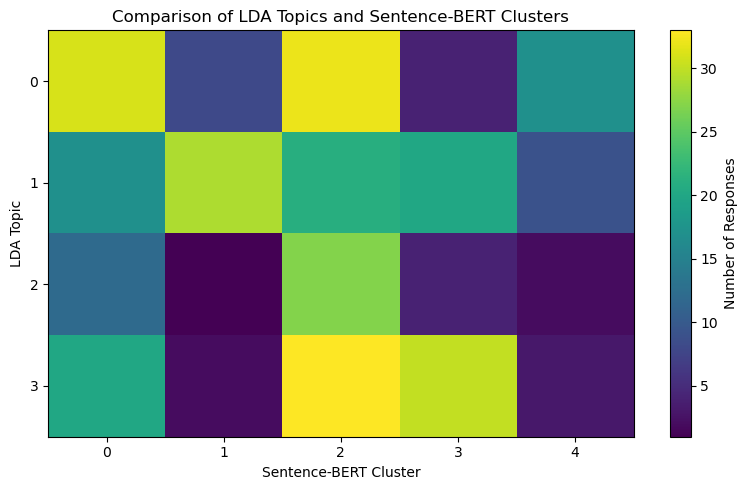


FINAL NLP ANALYSIS SUMMARY

Number of open-ended responses:
322

------------------------------
LDA
------------------------------

Best coherence-based topic number:
9

Best LDA coherence score:
0.3797

Final LDA model currently used:
4 topics


------------------------------
SENTENCE-BERT + K-MEANS
------------------------------

Best silhouette-based cluster number:
5

Best silhouette score:
0.1221

Final Sentence-BERT cluster number:
5


Results successfully saved:

1. lda_coherence_results.csv
2. bert_silhouette_results.csv
3. lda_vs_bert_comparison.csv
4. lda_vs_bert_percentage.csv
5. final_nlp_results.csv



In [126]:
# ============================================================
# PART 8
# FINAL SENTENCE-BERT + K-MEANS MODEL
# Use the best K identified by Silhouette Score
# ============================================================

print("\n" + "=" * 70)
print("PART 8: FINAL BERT CLUSTERS")
print("=" * 70)

# Automatically use the best number of clusters
# identified from the silhouette-score evaluation.
final_k = best_k

print(f"\nUsing optimal number of clusters: K = {final_k}")
print(f"Best silhouette score: {best_silhouette:.4f}")


# Build final K-Means model
final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

bert_clusters = final_kmeans.fit_predict(
    embeddings
)

# Add cluster labels to dataframe
text_df = text_df.copy()

text_df["BERT_Cluster"] = bert_clusters


# Display cluster sizes
print("\nBERT cluster distribution:")

cluster_distribution = (
    text_df["BERT_Cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_distribution)


# ============================================================
# PART 9
# REPRESENTATIVE RESPONSES FOR EACH BERT CLUSTER
# ============================================================

print("\n" + "=" * 70)
print("PART 9: REPRESENTATIVE BERT RESPONSES")
print("=" * 70)

# Calculate distance between every response
# and every cluster centre
distances = final_kmeans.transform(
    embeddings
)


for cluster_number in range(final_k):

    print("\n" + "=" * 70)
    print(f"BERT CLUSTER {cluster_number}")
    print("=" * 70)

    # Get all responses belonging to this cluster
    cluster_indices = np.where(
        bert_clusters == cluster_number
    )[0]

    # Distance to this cluster's centroid
    cluster_distances = distances[
        cluster_indices,
        cluster_number
    ]

    # Sort from closest to furthest
    sorted_indices = cluster_indices[
        np.argsort(cluster_distances)
    ]

    # Show the 10 most representative responses
    top_indices = sorted_indices[:10]

    for number, index in enumerate(
        top_indices,
        start=1
    ):
        print(
            f"{number}. {texts[index]}"
        )


# ============================================================
# PART 10
# LDA VS SENTENCE-BERT COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("PART 10: LDA VS BERT COMPARISON")
print("=" * 70)


# Cross-tabulation:
# rows = LDA topics
# columns = Sentence-BERT clusters

comparison_table = pd.crosstab(
    text_df["LDA_Dominant_Topic"],
    text_df["BERT_Cluster"]
)


print("\nLDA Topic × BERT Cluster:")
display(comparison_table)


# ------------------------------------------------------------
# Percentage comparison
# ------------------------------------------------------------

comparison_percent = pd.crosstab(
    text_df["LDA_Dominant_Topic"],
    text_df["BERT_Cluster"],
    normalize="index"
) * 100


print("\nPercentage distribution:")
display(
    comparison_percent.round(1)
)


# ============================================================
# PART 11
# VISUALISE LDA VS BERT
# ============================================================

plt.figure(figsize=(8, 5))

plt.imshow(
    comparison_table,
    aspect="auto"
)

plt.colorbar(
    label="Number of Responses"
)

plt.xlabel(
    "Sentence-BERT Cluster"
)

plt.ylabel(
    "LDA Topic"
)

plt.title(
    "Comparison of LDA Topics and Sentence-BERT Clusters"
)

plt.xticks(
    range(len(comparison_table.columns)),
    comparison_table.columns
)

plt.yticks(
    range(len(comparison_table.index)),
    comparison_table.index
)

plt.tight_layout()
plt.show()


# ============================================================
# PART 12
# FINAL NLP ANALYSIS SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL NLP ANALYSIS SUMMARY")
print("=" * 70)


print(
    f"""
Number of open-ended responses:
{len(texts)}

------------------------------
LDA
------------------------------

Best coherence-based topic number:
{best_num_topics}

Best LDA coherence score:
{best_coherence:.4f}

Final LDA model currently used:
{final_num_topics} topics


------------------------------
SENTENCE-BERT + K-MEANS
------------------------------

Best silhouette-based cluster number:
{best_k}

Best silhouette score:
{best_silhouette:.4f}

Final Sentence-BERT cluster number:
{final_k}
"""
)


# ============================================================
# PART 13
# SAVE RESULTS
# ============================================================

lda_evaluation_df.to_csv(
    "lda_coherence_results.csv",
    index=False
)

bert_evaluation_df.to_csv(
    "bert_silhouette_results.csv",
    index=False
)

comparison_table.to_csv(
    "lda_vs_bert_comparison.csv"
)

comparison_percent.to_csv(
    "lda_vs_bert_percentage.csv"
)

text_df.to_csv(
    "final_nlp_results.csv",
    index=False
)


print("\nResults successfully saved:")

print(
    """
1. lda_coherence_results.csv
2. bert_silhouette_results.csv
3. lda_vs_bert_comparison.csv
4. lda_vs_bert_percentage.csv
5. final_nlp_results.csv
"""
)

In [153]:
# ============================================================
# LDA INTERPRETABILITY CHECK
# Compare 4-topic, 7-topic and 9-topic solutions
# ============================================================

from gensim.models import LdaModel
import numpy as np

topic_options = [4, 7, 9]

lda_interpretability_models = {}

for num_topics in topic_options:

    print("\n" + "=" * 80)
    print(f"LDA MODEL WITH {num_topics} TOPICS")
    print("=" * 80)

    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=30,
        iterations=150,
        alpha="auto",
        per_word_topics=True
    )

    lda_interpretability_models[num_topics] = model

    # --------------------------------------------------------
    # Print top words for each topic
    # --------------------------------------------------------

    for topic_id in range(num_topics):

        print("\n" + "-" * 60)
        print(f"TOPIC {topic_id}")
        print("-" * 60)

        top_words = model.show_topic(
            topic_id,
            topn=12
        )

        print("Top words:")

        for word, probability in top_words:
            print(
                f"{word:<20} {probability:.4f}"
            )

        # ----------------------------------------------------
        # Find representative responses for this topic
        # ----------------------------------------------------

        topic_scores = []

        for doc_index, bow in enumerate(corpus):

            topic_distribution = dict(
                model.get_document_topics(
                    bow,
                    minimum_probability=0
                )
            )

            score = topic_distribution.get(
                topic_id,
                0
            )

            topic_scores.append(
                (doc_index, score)
            )

        # Sort by probability for this topic
        topic_scores = sorted(
            topic_scores,
            key=lambda x: x[1],
            reverse=True
        )

        print("\nRepresentative responses:")

        shown = 0

        for doc_index, score in topic_scores:

            response = texts[doc_index].strip()

            # Avoid empty text
            if response:

                print(
                    f"{shown + 1}. "
                    f"[Probability={score:.3f}] "
                    f"{response}"
                )

                shown += 1

            if shown >= 5:
                break


LDA MODEL WITH 4 TOPICS

------------------------------------------------------------
TOPIC 0
------------------------------------------------------------
Top words:
feel                 0.0292
time                 0.0254
motivation           0.0246
fatigue              0.0221
negative             0.0179
pace                 0.0179
injury               0.0178
always               0.0177
marathon             0.0140
older                0.0140
thoughts             0.0140
training             0.0133

Representative responses:
1. [Probability=0.992] The main two are 
1) worry of injury as that wouldn’t allow me to train for a period of time. This isn’t focussed on a race or achieving a goal. My main motivation for running regularly is that it allows me to sleep better. My tiredness levels increase and performance at work deteriorates if I’m not doing regular vigorous exercise.
2) the time I spend running vs other family commitments can make me feel guilty. This is why I’m not training for


All required packages are available.

Libraries imported successfully.

Dataset loaded successfully.
Dataset shape: (593, 24)

Open-ended text column found:
Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)

Number of original open-ended responses: 322

Responses remaining after preprocessing: 320
Vocabulary size: 319
Corpus size: 320

NLP DATA PREPARATION COMPLETE
texts: 320
processed_texts: 320
text_df: 320
corpus: 320
dictionary: 319

PART 9: LDA COHERENCE EVALUATION
Topics = 2 | Coherence = 0.3653
Topics = 3 | Coherence = 0.3437
Topics = 4 | Coherence = 0.3550
Topics = 5 | Coherence = 0.3409
Topics = 6 | Coherence = 0.3835
Topics = 7 | Coherence = 0.3738
Topics = 8 | Coherence = 0.3677
Topics = 9 | Coherence = 0.3902
Topics = 10 | Coherence = 0.3581

----------------------------------------------------------------------
Best number of topics according to coherence: 9
Best coherence score: 0.3902

LDA Evalu

,Number_of_Topics,Coherence_Score
0,2,0.365340
1,3,0.343693
2,4,0.355022
3,5,0.340898
4,6,0.383480
5,7,0.373797
6,8,0.367725
7,9,0.390176
8,10,0.358112


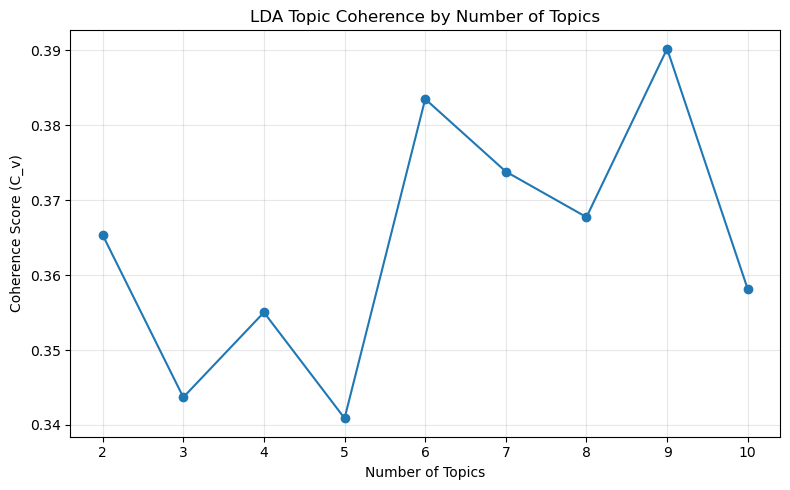


PART 12: FINAL LDA MODEL

Final LDA model uses 7 topics.

Top words for each LDA topic:

------------------------------------------------------------
LDA TOPIC 0
------------------------------------------------------------
motivation           0.0337
time                 0.0313
injury               0.0313
confidence           0.0288
negative             0.0221
pace                 0.0221
fatigue              0.0212
feel                 0.0206
older                0.0190
self                 0.0190
around               0.0159
thoughts             0.0159

------------------------------------------------------------
LDA TOPIC 1
------------------------------------------------------------
motivation           0.1427
confidence           0.0488
fatigue              0.0420
lack                 0.0359
sometimes            0.0213
performance          0.0199
pressure             0.0172
faster               0.0172
hard                 0.0171
ability              0.0144
weight               0.01

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence-BERT model loaded.


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Number of responses: 320
Embedding matrix shape: (320, 384)

PART 17: SENTENCE-BERT + K-MEANS EVALUATION
Clusters = 2 | Silhouette Score = 0.0736


...

C:\Users\chloe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Clusters = 9 | Silhouette Score = 0.1125


C:\Users\chloe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Clusters = 10 | Silhouette Score = 0.1150

----------------------------------------------------------------------
Best number of BERT clusters: 5
Best silhouette score: 0.1236

Sentence-BERT Evaluation Table:


,Number_of_Clusters,Silhouette_Score
0,2,0.073609
1,3,0.097476
2,4,0.110479
3,5,0.123579
4,6,0.112120
5,7,0.115436
6,8,0.106741
7,9,0.112538
8,10,0.115049


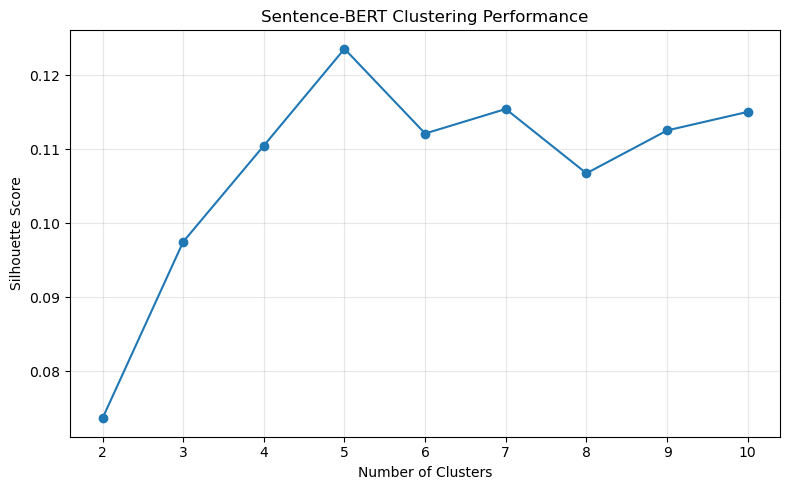


PART 20: FINAL SENTENCE-BERT CLUSTERS

Using optimal number of Sentence-BERT clusters: 5
Best silhouette score: 0.1236


C:\Users\chloe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



Final BERT cluster distribution:
BERT_Cluster
0     57
1    116
2     76
3     40
4     31
Name: count, dtype: int64

PART 21: REPRESENTATIVE BERT RESPONSES

BERT CLUSTER 0
1. Fatigue
2. Fatigue
3. fatigue
4. Fatigue
5. Fatigue
6. Fatigue
7. Fatigue
8. Fatigue
9. Fatigue
10. Fatigue

BERT CLUSTER 1
1. Motivation prior to running more of an issue rather than during running. And for following question I would regard myself as both a recreational and competitive runner.
2. Confidence and motivation, but I work hard to maintain a positive mental attitude during my runs, focusing on just being out there regardless of my performance
3. Self doubt, anxiety about not being able to compete a run
4. I always have lack of confidence when running whether a race or not.
5. Running at pace during a race creates issues around motivation and fatigue. It requires focus and effort to maintain race pace and you have to fight negative thoughts such as your mind wanting you to slow down or take a break. Y

BERT_Cluster,0,1,2,3,4
LDA_Dominant_Topic,,,,,
0,6,12,19,6,5
1,12,25,8,24,8
2,0,11,6,0,0
3,28,11,7,2,1
4,7,20,15,3,0
5,1,15,17,1,0
6,3,22,4,4,17



Percentage distribution:


BERT_Cluster,0,1,2,3,4
LDA_Dominant_Topic,,,,,
0,12.5,25.0,39.6,12.5,10.4
1,15.6,32.5,10.4,31.2,10.4
2,0.0,64.7,35.3,0.0,0.0
3,57.1,22.4,14.3,4.1,2.0
4,15.6,44.4,33.3,6.7,0.0
5,2.9,44.1,50.0,2.9,0.0
6,6.0,44.0,8.0,8.0,34.0


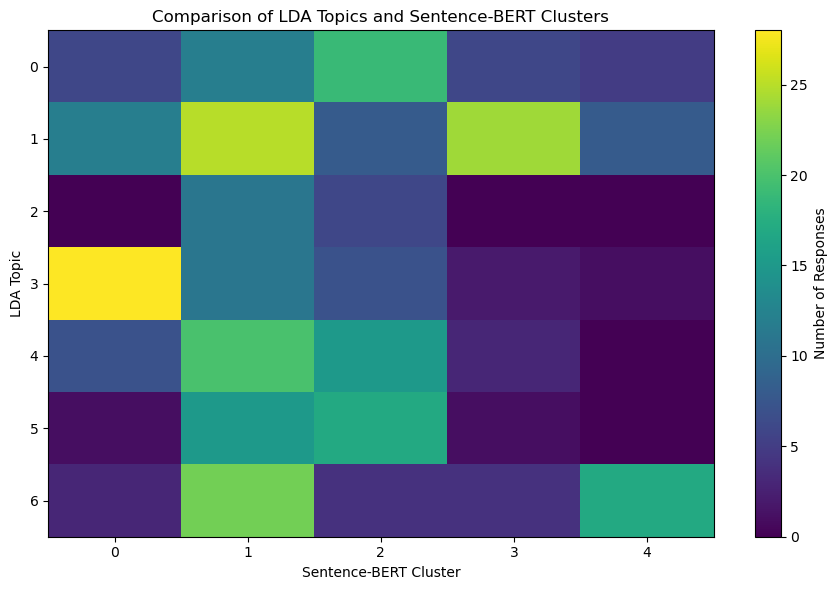


FINAL NLP ANALYSIS SUMMARY

Number of open-ended responses:
320

LDA

Highest coherence-based topic number:
9

Highest coherence score:
0.3902

Final LDA topic number selected:
7

Reason:
7 topics retained based on a balance of
coherence, interpretability and parsimony.


SENTENCE-BERT + K-MEANS

Best silhouette-based cluster number:
5

Best silhouette score:
0.1236

Final Sentence-BERT cluster number:
5


Results successfully saved:

1. lda_coherence_results.csv
2. bert_silhouette_results.csv
3. lda_vs_bert_comparison.csv
4. lda_vs_bert_percentage.csv
5. final_nlp_results.csv



In [154]:
# ============================================================
# COMPLETE FINAL NLP ANALYSIS
#
# Final approach:
# 1. LDA topic modelling
# 2. LDA coherence evaluation (2-10 topics)
# 3. Final LDA = 7 topics
# 4. Sentence-BERT embeddings
# 5. K-Means clustering
# 6. Silhouette evaluation (2-10 clusters)
# 7. Final BERT K = automatically selected best K
# 8. LDA vs BERT comparison
# ============================================================


# ============================================================
# PART 0: INSTALL REQUIRED PACKAGES
# ============================================================

import sys
import subprocess
import importlib.util

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "nltk": "nltk",
    "gensim": "gensim",
    "sklearn": "scikit-learn",
    "sentence_transformers": "sentence-transformers"
}

for module_name, package_name in required_packages.items():

    if importlib.util.find_spec(module_name) is None:

        print(f"Installing {package_name}...")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            package_name
        ])

print("\nAll required packages are available.")


# ============================================================
# PART 1: IMPORT LIBRARIES
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from nltk.corpus import stopwords

from gensim import corpora
from gensim.models import LdaModel
from gensim.models import CoherenceModel

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sentence_transformers import SentenceTransformer


print("\nLibraries imported successfully.")


# ============================================================
# PART 2: LOAD SURVEY DATA
# ============================================================

nltk.download(
    "stopwords",
    quiet=True
)

# Change this only if your CSV filename is different
csv_file = "Untitled spreadsheet - Form responses 1.csv"


df = pd.read_csv(
    csv_file,
    encoding="utf-8-sig"
)

print("\nDataset loaded successfully.")
print("Dataset shape:", df.shape)


# ============================================================
# PART 3: CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
)


# ============================================================
# PART 4: FIND OPEN-ENDED PSYCHOLOGICAL QUESTION
# ============================================================

text_matches = [
    col
    for col in df.columns
    if "psychological challenges" in col.lower()
]

if len(text_matches) == 0:

    print("\nAvailable columns:")

    for col in df.columns:
        print(col)

    raise ValueError(
        "Could not find the open-ended psychological challenges column."
    )


text_col = text_matches[0]

print("\nOpen-ended text column found:")
print(text_col)


# ============================================================
# PART 5: KEEP VALID OPEN-ENDED RESPONSES
# ============================================================

text_df = df[
    df[text_col].notna()
].copy()

text_df[text_col] = (
    text_df[text_col]
    .astype(str)
    .str.strip()
)

text_df = text_df[
    text_df[text_col] != ""
].reset_index(
    drop=True
)


texts = (
    text_df[text_col]
    .astype(str)
    .tolist()
)


print(
    "\nNumber of original open-ended responses:",
    len(texts)
)


# ============================================================
# PART 6: TEXT PREPROCESSING FOR LDA
# ============================================================

stop_words = set(
    stopwords.words("english")
)


# Domain-specific high-frequency words
# that do not strongly distinguish themes

custom_stopwords = {
    "running",
    "runner",
    "runners",
    "run",
    "runs",
    "race",
    "races"
}

stop_words = stop_words.union(
    custom_stopwords
)


processed_texts = []


for text in texts:

    # Lowercase
    cleaned_text = text.lower()

    # Remove punctuation and numbers
    cleaned_text = re.sub(
        r"[^a-z\s]",
        " ",
        cleaned_text
    )

    # Remove extra spaces
    cleaned_text = re.sub(
        r"\s+",
        " ",
        cleaned_text
    ).strip()

    # Tokenisation
    tokens = cleaned_text.split()

    # Remove stop words and very short words
    tokens = [
        word
        for word in tokens
        if word not in stop_words
        and len(word) > 2
    ]

    processed_texts.append(
        tokens
    )


# ============================================================
# PART 7: REMOVE EMPTY RESPONSES AFTER PREPROCESSING
# ============================================================

valid_indices = [
    i
    for i, tokens in enumerate(processed_texts)
    if len(tokens) > 0
]


processed_texts = [
    processed_texts[i]
    for i in valid_indices
]

texts = [
    texts[i]
    for i in valid_indices
]

text_df = (
    text_df
    .iloc[valid_indices]
    .reset_index(drop=True)
)


print(
    "\nResponses remaining after preprocessing:",
    len(processed_texts)
)


# ============================================================
# PART 8: CREATE LDA DICTIONARY AND CORPUS
# ============================================================

dictionary = corpora.Dictionary(
    processed_texts
)


dictionary.filter_extremes(
    no_below=2,
    no_above=0.90
)


corpus = [
    dictionary.doc2bow(tokens)
    for tokens in processed_texts
]


print("Vocabulary size:", len(dictionary))
print("Corpus size:", len(corpus))


print("\n" + "=" * 70)
print("NLP DATA PREPARATION COMPLETE")
print("=" * 70)

print("texts:", len(texts))
print("processed_texts:", len(processed_texts))
print("text_df:", len(text_df))
print("corpus:", len(corpus))
print("dictionary:", len(dictionary))


# ============================================================
# PART 9: LDA COHERENCE EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("PART 9: LDA COHERENCE EVALUATION")
print("=" * 70)


topic_numbers = list(
    range(2, 11)
)

coherence_scores = []
lda_models = []


for num_topics in topic_numbers:

    lda_temp = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=20,
        iterations=100,
        alpha="auto"
    )


    coherence_model = CoherenceModel(
        model=lda_temp,
        texts=processed_texts,
        dictionary=dictionary,
        coherence="c_v"
    )


    coherence_score = (
        coherence_model
        .get_coherence()
    )


    coherence_scores.append(
        coherence_score
    )

    lda_models.append(
        lda_temp
    )


    print(
        f"Topics = {num_topics} | "
        f"Coherence = {coherence_score:.4f}"
    )


# ============================================================
# PART 10: FIND BEST COHERENCE-BASED TOPIC NUMBER
# ============================================================

best_topic_index = int(
    np.argmax(
        coherence_scores
    )
)


best_num_topics = (
    topic_numbers[
        best_topic_index
    ]
)


best_coherence = (
    coherence_scores[
        best_topic_index
    ]
)


print("\n" + "-" * 70)

print(
    "Best number of topics according to coherence:",
    best_num_topics
)

print(
    "Best coherence score:",
    round(
        best_coherence,
        4
    )
)


lda_evaluation_df = pd.DataFrame({
    "Number_of_Topics": topic_numbers,
    "Coherence_Score": coherence_scores
})


print("\nLDA Evaluation Table:")

display(
    lda_evaluation_df
)


# ============================================================
# PART 11: PLOT LDA COHERENCE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    topic_numbers,
    coherence_scores,
    marker="o"
)

plt.xlabel(
    "Number of Topics"
)

plt.ylabel(
    "Coherence Score (C_v)"
)

plt.title(
    "LDA Topic Coherence by Number of Topics"
)

plt.xticks(
    topic_numbers
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# PART 12: FINAL LDA MODEL
# ============================================================

print("\n" + "=" * 70)
print("PART 12: FINAL LDA MODEL")
print("=" * 70)


# FINAL DECISION:
# 7 topics are used because they provide a strong balance
# between coherence and interpretability.
#
# The 9-topic solution may have slightly higher coherence,
# but the 7-topic model is retained for greater parsimony
# and reduced thematic fragmentation.

final_num_topics = 7


lda_model_final = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=final_num_topics,
    random_state=42,
    passes=30,
    iterations=150,
    alpha="auto",
    per_word_topics=True
)


print(
    f"\nFinal LDA model uses "
    f"{final_num_topics} topics."
)


print(
    "\nTop words for each LDA topic:"
)


for topic_id in range(
    final_num_topics
):

    words = (
        lda_model_final
        .show_topic(
            topic_id,
            topn=12
        )
    )


    print(
        "\n"
        + "-" * 60
    )

    print(
        f"LDA TOPIC {topic_id}"
    )

    print(
        "-" * 60
    )


    for word, probability in words:

        print(
            f"{word:<20} "
            f"{probability:.4f}"
        )


# ============================================================
# PART 13: ASSIGN DOMINANT LDA TOPIC
# ============================================================

print("\n" + "=" * 70)
print("PART 13: ASSIGN DOMINANT LDA TOPIC")
print("=" * 70)


dominant_topics = []
dominant_probabilities = []


for bow in corpus:

    topic_distribution = (
        lda_model_final
        .get_document_topics(
            bow,
            minimum_probability=0
        )
    )


    if len(topic_distribution) > 0:

        dominant_topic, probability = max(
            topic_distribution,
            key=lambda x: x[1]
        )


        dominant_topics.append(
            dominant_topic
        )

        dominant_probabilities.append(
            probability
        )


    else:

        dominant_topics.append(
            np.nan
        )

        dominant_probabilities.append(
            np.nan
        )


text_df = text_df.copy()


text_df[
    "LDA_Dominant_Topic"
] = dominant_topics


text_df[
    "LDA_Topic_Probability"
] = dominant_probabilities


print(
    "\nDominant LDA topic distribution:"
)


print(
    text_df[
        "LDA_Dominant_Topic"
    ]
    .value_counts()
    .sort_index()
)


# ============================================================
# PART 14: REPRESENTATIVE RESPONSES FOR EACH LDA TOPIC
# ============================================================

print("\n" + "=" * 70)
print("PART 14: REPRESENTATIVE LDA RESPONSES")
print("=" * 70)


for topic_id in range(
    final_num_topics
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"LDA TOPIC {topic_id}"
    )

    print(
        "=" * 70
    )


    topic_scores = []


    for doc_index, bow in enumerate(
        corpus
    ):

        topic_distribution = dict(
            lda_model_final.get_document_topics(
                bow,
                minimum_probability=0
            )
        )


        topic_probability = (
            topic_distribution
            .get(
                topic_id,
                0
            )
        )


        topic_scores.append(
            (
                doc_index,
                topic_probability
            )
        )


    topic_scores = sorted(
        topic_scores,
        key=lambda x: x[1],
        reverse=True
    )


    for rank, (
        doc_index,
        probability
    ) in enumerate(
        topic_scores[:5],
        start=1
    ):

        print(
            f"{rank}. "
            f"[Probability={probability:.3f}] "
            f"{texts[doc_index]}"
        )


# ============================================================
# PART 15: LOAD SENTENCE-BERT
# ============================================================

print("\n" + "=" * 70)
print("PART 15: SENTENCE-BERT EMBEDDINGS")
print("=" * 70)


print(
    "\nLoading Sentence-BERT model..."
)


bert_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)


print(
    "Sentence-BERT model loaded."
)


# ============================================================
# PART 16: CREATE SENTENCE EMBEDDINGS
# ============================================================

embeddings = bert_model.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True
)


print(
    "\nNumber of responses:",
    len(texts)
)


print(
    "Embedding matrix shape:",
    embeddings.shape
)


# ============================================================
# PART 17: K-MEANS SILHOUETTE EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("PART 17: SENTENCE-BERT + K-MEANS EVALUATION")
print("=" * 70)


k_values = list(
    range(2, 11)
)


silhouette_scores = []
kmeans_models = []


for k in k_values:

    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )


    labels = (
        kmeans_temp
        .fit_predict(
            embeddings
        )
    )


    silhouette = silhouette_score(
        embeddings,
        labels,
        metric="euclidean"
    )


    silhouette_scores.append(
        silhouette
    )

    kmeans_models.append(
        kmeans_temp
    )


    print(
        f"Clusters = {k} | "
        f"Silhouette Score = {silhouette:.4f}"
    )


# ============================================================
# PART 18: FIND BEST BERT CLUSTER NUMBER
# ============================================================

best_cluster_index = int(
    np.argmax(
        silhouette_scores
    )
)


best_k = (
    k_values[
        best_cluster_index
    ]
)


best_silhouette = (
    silhouette_scores[
        best_cluster_index
    ]
)


print(
    "\n"
    + "-" * 70
)


print(
    "Best number of BERT clusters:",
    best_k
)


print(
    "Best silhouette score:",
    round(
        best_silhouette,
        4
    )
)


bert_evaluation_df = pd.DataFrame({
    "Number_of_Clusters": k_values,
    "Silhouette_Score": silhouette_scores
})


print(
    "\nSentence-BERT Evaluation Table:"
)


display(
    bert_evaluation_df
)


# ============================================================
# PART 19: PLOT SILHOUETTE SCORES
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)


plt.xlabel(
    "Number of Clusters"
)


plt.ylabel(
    "Silhouette Score"
)


plt.title(
    "Sentence-BERT Clustering Performance"
)


plt.xticks(
    k_values
)


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ============================================================
# PART 20: FINAL BERT + K-MEANS MODEL
# ============================================================

print("\n" + "=" * 70)
print("PART 20: FINAL SENTENCE-BERT CLUSTERS")
print("=" * 70)


# Automatically select best K based on silhouette score
final_k = best_k


print(
    f"\nUsing optimal number of "
    f"Sentence-BERT clusters: {final_k}"
)


print(
    f"Best silhouette score: "
    f"{best_silhouette:.4f}"
)


final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)


bert_clusters = (
    final_kmeans
    .fit_predict(
        embeddings
    )
)


text_df[
    "BERT_Cluster"
] = bert_clusters


print(
    "\nFinal BERT cluster distribution:"
)


bert_cluster_distribution = (
    text_df[
        "BERT_Cluster"
    ]
    .value_counts()
    .sort_index()
)


print(
    bert_cluster_distribution
)


# ============================================================
# PART 21: REPRESENTATIVE BERT RESPONSES
# ============================================================

print("\n" + "=" * 70)
print("PART 21: REPRESENTATIVE BERT RESPONSES")
print("=" * 70)


distances = (
    final_kmeans
    .transform(
        embeddings
    )
)


for cluster_number in range(
    final_k
):

    print(
        "\n"
        + "=" * 70
    )


    print(
        f"BERT CLUSTER "
        f"{cluster_number}"
    )


    print(
        "=" * 70
    )


    cluster_indices = np.where(
        bert_clusters
        == cluster_number
    )[0]


    cluster_distances = distances[
        cluster_indices,
        cluster_number
    ]


    sorted_indices = (
        cluster_indices[
            np.argsort(
                cluster_distances
            )
        ]
    )


    top_indices = (
        sorted_indices[:10]
    )


    for number, index in enumerate(
        top_indices,
        start=1
    ):

        print(
            f"{number}. "
            f"{texts[index]}"
        )


# ============================================================
# PART 22: LDA VS SENTENCE-BERT COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("PART 22: LDA VS SENTENCE-BERT COMPARISON")
print("=" * 70)


comparison_table = pd.crosstab(
    text_df[
        "LDA_Dominant_Topic"
    ],
    text_df[
        "BERT_Cluster"
    ]
)


print(
    "\nLDA Topic × BERT Cluster:"
)


display(
    comparison_table
)


comparison_percent = pd.crosstab(
    text_df[
        "LDA_Dominant_Topic"
    ],
    text_df[
        "BERT_Cluster"
    ],
    normalize="index"
) * 100


print(
    "\nPercentage distribution:"
)


display(
    comparison_percent.round(1)
)


# ============================================================
# PART 23: VISUALISE LDA VS BERT
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.imshow(
    comparison_table,
    aspect="auto"
)


plt.colorbar(
    label="Number of Responses"
)


plt.xlabel(
    "Sentence-BERT Cluster"
)


plt.ylabel(
    "LDA Topic"
)


plt.title(
    "Comparison of LDA Topics and Sentence-BERT Clusters"
)


plt.xticks(
    range(
        len(
            comparison_table.columns
        )
    ),
    comparison_table.columns
)


plt.yticks(
    range(
        len(
            comparison_table.index
        )
    ),
    comparison_table.index
)


plt.tight_layout()

plt.show()


# ============================================================
# PART 24: FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL NLP ANALYSIS SUMMARY")
print("=" * 70)


print(
    f"""
Number of open-ended responses:
{len(texts)}

==================================================
LDA
==================================================

Highest coherence-based topic number:
{best_num_topics}

Highest coherence score:
{best_coherence:.4f}

Final LDA topic number selected:
{final_num_topics}

Reason:
7 topics retained based on a balance of
coherence, interpretability and parsimony.


==================================================
SENTENCE-BERT + K-MEANS
==================================================

Best silhouette-based cluster number:
{best_k}

Best silhouette score:
{best_silhouette:.4f}

Final Sentence-BERT cluster number:
{final_k}
"""
)


# ============================================================
# PART 25: SAVE RESULTS
# ============================================================

lda_evaluation_df.to_csv(
    "lda_coherence_results.csv",
    index=False
)


bert_evaluation_df.to_csv(
    "bert_silhouette_results.csv",
    index=False
)


comparison_table.to_csv(
    "lda_vs_bert_comparison.csv"
)


comparison_percent.to_csv(
    "lda_vs_bert_percentage.csv"
)


text_df.to_csv(
    "final_nlp_results.csv",
    index=False
)


print(
    "\nResults successfully saved:"
)


print(
    """
1. lda_coherence_results.csv
2. bert_silhouette_results.csv
3. lda_vs_bert_comparison.csv
4. lda_vs_bert_percentage.csv
5. final_nlp_results.csv
"""
)

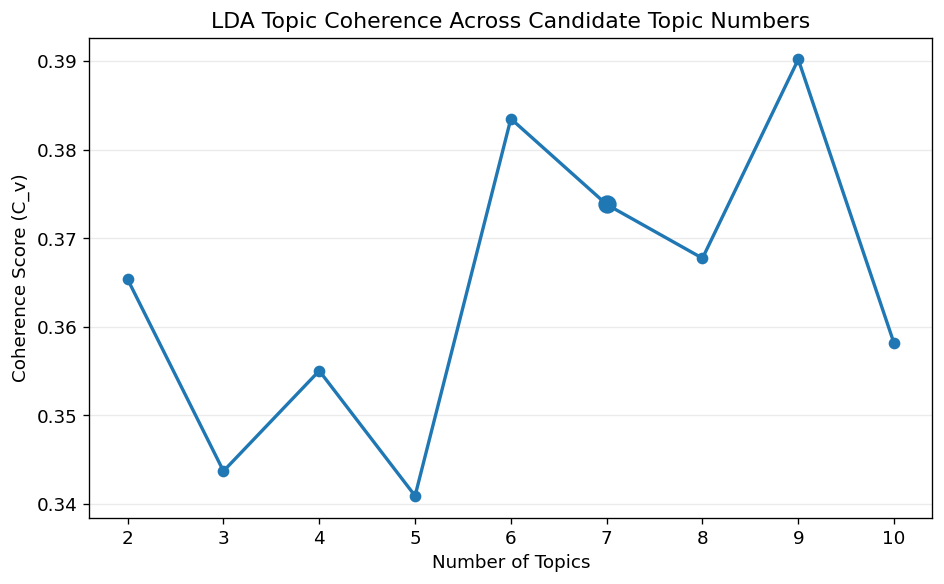

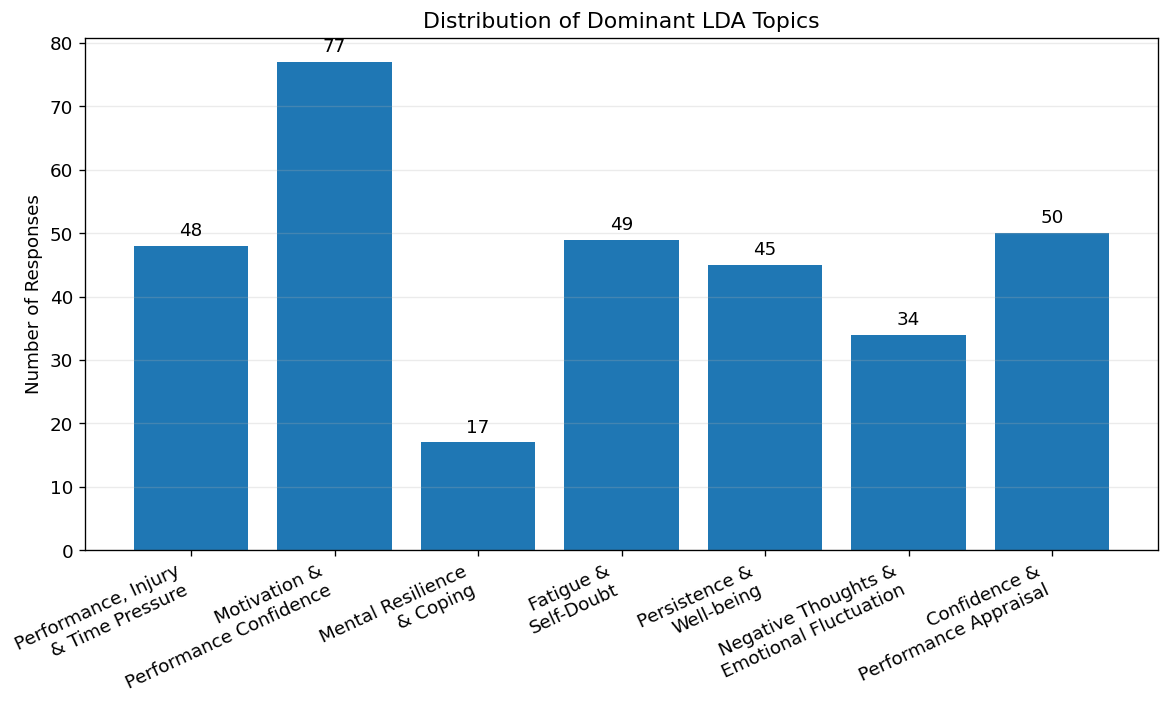

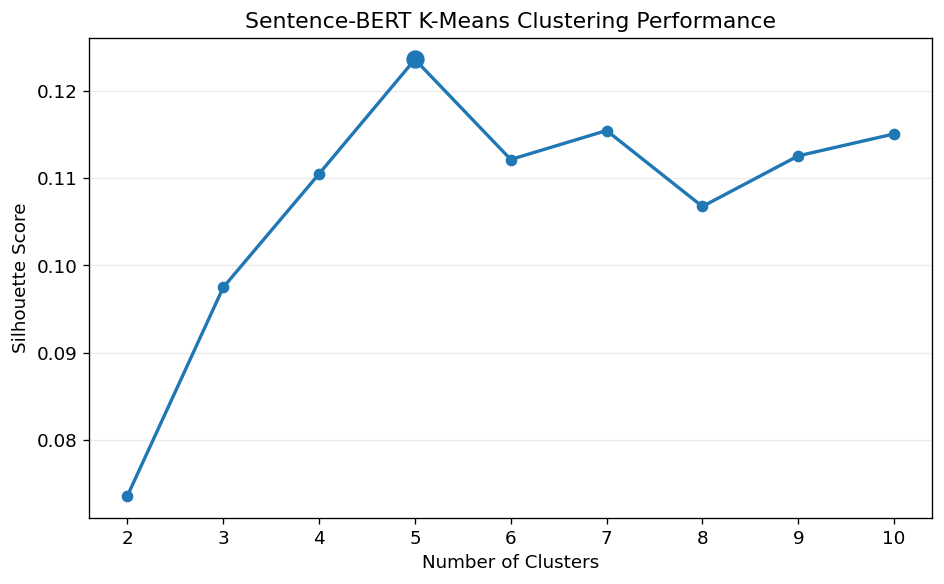

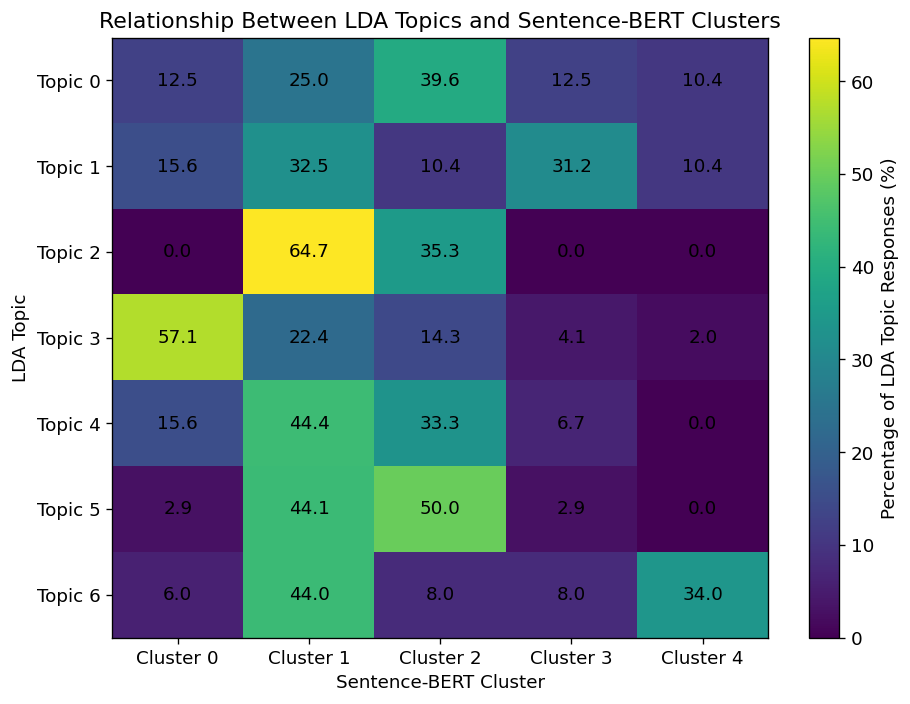


All dissertation NLP figures saved successfully:

1. Figure_LDA_Coherence.png
2. Figure_LDA_Topic_Distribution.png
3. Figure_BERT_Silhouette.png
4. Figure_LDA_BERT_Heatmap.png



In [155]:
# ============================================================
# FINAL DISSERTATION NLP FIGURES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# GLOBAL SETTINGS
# ------------------------------------------------------------

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11


# ============================================================
# FIGURE 1
# LDA COHERENCE SCORE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    topic_numbers,
    coherence_scores,
    marker="o",
    linewidth=2
)

# Mark final selected model
selected_index = topic_numbers.index(final_num_topics)

plt.scatter(
    [final_num_topics],
    [coherence_scores[selected_index]],
    s=100,
    zorder=5
)

plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (C_v)")

plt.title(
    "LDA Topic Coherence Across Candidate Topic Numbers"
)

plt.xticks(topic_numbers)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "Figure_LDA_Coherence.png",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 2
# FINAL LDA TOPIC DISTRIBUTION
# ============================================================

lda_counts = (
    text_df["LDA_Dominant_Topic"]
    .value_counts()
    .sort_index()
)

# Suggested academic topic labels
lda_topic_names = [
    "Performance, Injury\n& Time Pressure",
    "Motivation &\nPerformance Confidence",
    "Mental Resilience\n& Coping",
    "Fatigue &\nSelf-Doubt",
    "Persistence &\nWell-being",
    "Negative Thoughts &\nEmotional Fluctuation",
    "Confidence &\nPerformance Appraisal"
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    range(len(lda_counts)),
    lda_counts.values
)

plt.xticks(
    range(len(lda_counts)),
    lda_topic_names,
    rotation=25,
    ha="right"
)

plt.ylabel("Number of Responses")

plt.title(
    "Distribution of Dominant LDA Topics"
)

plt.grid(
    axis="y",
    alpha=0.25
)

# Add value labels
for bar, value in zip(
    bars,
    lda_counts.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "Figure_LDA_Topic_Distribution.png",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 3
# SENTENCE-BERT SILHOUETTE SCORE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o",
    linewidth=2
)

# Mark best K
plt.scatter(
    [best_k],
    [best_silhouette],
    s=100,
    zorder=5
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title(
    "Sentence-BERT K-Means Clustering Performance"
)

plt.xticks(k_values)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "Figure_BERT_Silhouette.png",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 4
# LDA VS SENTENCE-BERT HEATMAP
# ============================================================

comparison_percent = pd.crosstab(
    text_df["LDA_Dominant_Topic"],
    text_df["BERT_Cluster"],
    normalize="index"
) * 100

plt.figure(figsize=(8, 6))

image = plt.imshow(
    comparison_percent.values,
    aspect="auto"
)

plt.colorbar(
    image,
    label="Percentage of LDA Topic Responses (%)"
)

plt.xlabel("Sentence-BERT Cluster")
plt.ylabel("LDA Topic")

plt.title(
    "Relationship Between LDA Topics and Sentence-BERT Clusters"
)

plt.xticks(
    range(len(comparison_percent.columns)),
    [
        f"Cluster {i}"
        for i in comparison_percent.columns
    ]
)

plt.yticks(
    range(len(comparison_percent.index)),
    [
        f"Topic {i}"
        for i in comparison_percent.index
    ]
)

# Add percentages inside cells
for i in range(
    comparison_percent.shape[0]
):

    for j in range(
        comparison_percent.shape[1]
    ):

        value = comparison_percent.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "Figure_LDA_BERT_Heatmap.png",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINISHED
# ============================================================

print(
    """
All dissertation NLP figures saved successfully:

1. Figure_LDA_Coherence.png
2. Figure_LDA_Topic_Distribution.png
3. Figure_BERT_Silhouette.png
4. Figure_LDA_BERT_Heatmap.png
"""
)

7-TOPIC LDA × WEEKLY RUNNING FREQUENCY

Weekly running frequency categories:
How often do you run per week?
3–4 times    211
5+ times      55
1–2 times     54
Name: count, dtype: int64

TABLE 6A: COUNTS


LDA_Dominant_Topic,0,1,2,3,4,5,6
How often do you run per week?,,,,,,,
1–2 times,7,17,2,7,8,5,8
3–4 times,32,48,12,35,30,20,34
5+ times,9,12,3,7,7,9,8



TABLE 6B: ROW PERCENTAGES


LDA_Dominant_Topic,0,1,2,3,4,5,6
How often do you run per week?,,,,,,,
1–2 times,13.0,31.5,3.7,13.0,14.8,9.3,14.8
3–4 times,15.2,22.7,5.7,16.6,14.2,9.5,16.1
5+ times,16.4,21.8,5.5,12.7,12.7,16.4,14.5



PUBLICATION-READY TABLE 6


LDA_Dominant_Topic,"Performance, Injury and Time Pressure",Motivation and Performance Confidence,Mental Resilience and Coping,Fatigue and Self-Doubt,Persistence and Psychological Well-being,Negative Thoughts and Emotional Fluctuation,Confidence and Performance Appraisal
How often do you run per week?,,,,,,,
1–2 times,13.0,31.5,3.7,13.0,14.8,9.3,14.8
3–4 times,15.2,22.7,5.7,16.6,14.2,9.5,16.1
5+ times,16.4,21.8,5.5,12.7,12.7,16.4,14.5



CHI-SQUARE TEST
Chi-square statistic = 4.954
Degrees of freedom = 12
p-value = 0.9595
Cramer's V = 0.088

Expected-frequency diagnostic:
Cells with expected count < 5: 2/21 (9.5%)
Minimum expected count: 2.87


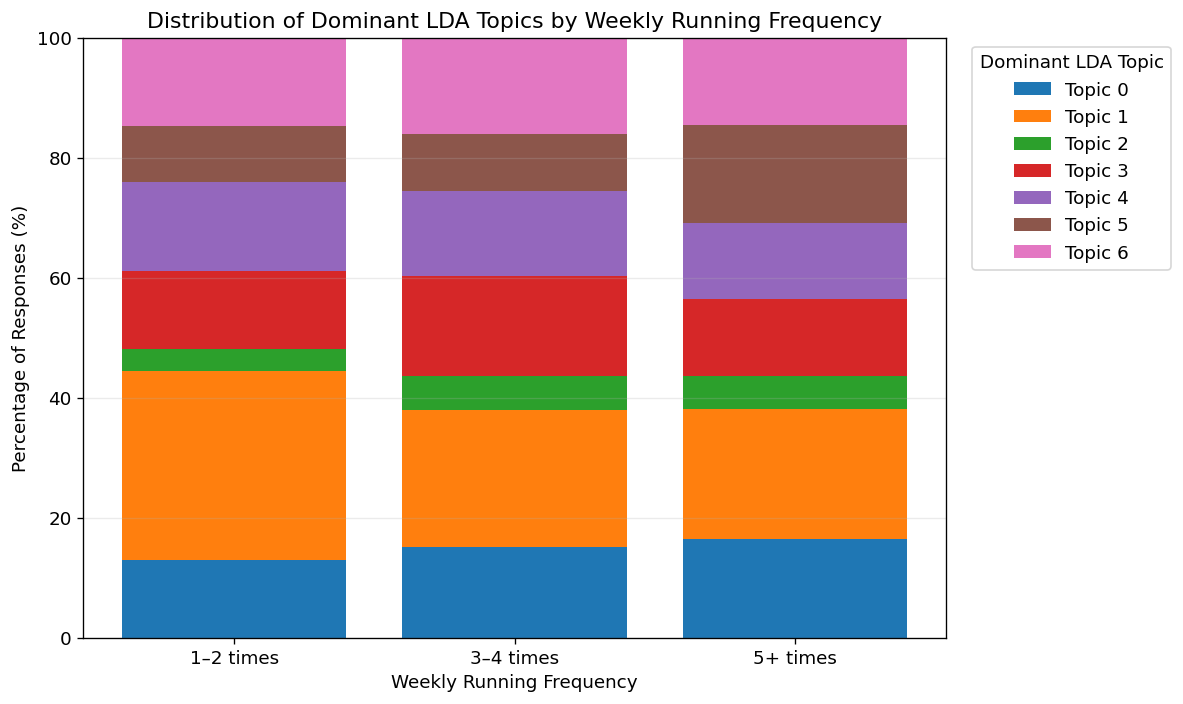


FINAL REPORTING RESULT

A chi-square test of independence examined the association between
weekly running frequency and dominant LDA topic membership.

χ²(12) = 4.95, p = 0.959, Cramer's V = 0.088.

RESULT: There is no statistically significant association between weekly running frequency and dominant LDA topic membership.

Files saved:

1. lda_frequency_counts_7topics.csv
2. lda_frequency_percentages_7topics.csv
3. Table_6_LDA_Topics_by_Weekly_Frequency.csv
4. lda_frequency_expected_counts.csv
5. Figure_11_LDA_Topics_by_Weekly_Frequency.png



In [156]:
# ============================================================
# FINAL ANALYSIS:
# 7-TOPIC LDA × WEEKLY RUNNING FREQUENCY
# Chi-square + Cramer's V + Figure 11
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency


# ============================================================
# PART 1
# FIND WEEKLY RUNNING FREQUENCY COLUMN
# ============================================================

frequency_col = "How often do you run per week?"


if frequency_col not in text_df.columns:

    raise ValueError(
        f"Column not found: {frequency_col}\n"
        "Please check the column name in text_df."
    )


print("=" * 70)
print("7-TOPIC LDA × WEEKLY RUNNING FREQUENCY")
print("=" * 70)


print("\nWeekly running frequency categories:")

print(
    text_df[frequency_col]
    .value_counts(dropna=False)
)


# ============================================================
# PART 2
# DEFINE CORRECT FREQUENCY ORDER
# ============================================================

frequency_order = [
    "1–2 times",
    "3–4 times",
    "5+ times"
]


# ============================================================
# PART 3
# CREATE CONTINGENCY TABLE
# ============================================================

lda_frequency_counts = pd.crosstab(
    text_df[frequency_col],
    text_df["LDA_Dominant_Topic"]
)


# Ensure frequency groups appear in correct order
lda_frequency_counts = (
    lda_frequency_counts
    .reindex(frequency_order)
)


# Ensure all 7 topics appear
lda_frequency_counts = (
    lda_frequency_counts
    .reindex(
        columns=range(7),
        fill_value=0
    )
)


print("\n" + "=" * 70)
print("TABLE 6A: COUNTS")
print("=" * 70)

display(
    lda_frequency_counts
)


# ============================================================
# PART 4
# CALCULATE ROW PERCENTAGES
# ============================================================

lda_frequency_percent = (
    lda_frequency_counts
    .div(
        lda_frequency_counts.sum(axis=1),
        axis=0
    )
    * 100
)


print("\n" + "=" * 70)
print("TABLE 6B: ROW PERCENTAGES")
print("=" * 70)

display(
    lda_frequency_percent.round(1)
)


# ============================================================
# PART 5
# ADD ACADEMIC TOPIC LABELS
# ============================================================

topic_names = {
    0: "Performance, Injury and Time Pressure",
    1: "Motivation and Performance Confidence",
    2: "Mental Resilience and Coping",
    3: "Fatigue and Self-Doubt",
    4: "Persistence and Psychological Well-being",
    5: "Negative Thoughts and Emotional Fluctuation",
    6: "Confidence and Performance Appraisal"
}


publication_table = (
    lda_frequency_percent
    .rename(columns=topic_names)
    .round(1)
)


print("\n" + "=" * 70)
print("PUBLICATION-READY TABLE 6")
print("=" * 70)

display(
    publication_table
)


# ============================================================
# PART 6
# CHI-SQUARE TEST OF INDEPENDENCE
# ============================================================

chi2, p_value, dof, expected = chi2_contingency(
    lda_frequency_counts
)


print("\n" + "=" * 70)
print("CHI-SQUARE TEST")
print("=" * 70)

print(
    f"Chi-square statistic = {chi2:.3f}"
)

print(
    f"Degrees of freedom = {dof}"
)

print(
    f"p-value = {p_value:.4f}"
)


# ============================================================
# PART 7
# CRAMER'S V
# ============================================================

n = lda_frequency_counts.to_numpy().sum()

rows, cols = lda_frequency_counts.shape


cramers_v = np.sqrt(
    chi2 /
    (
        n * min(
            rows - 1,
            cols - 1
        )
    )
)


print(
    f"Cramer's V = {cramers_v:.3f}"
)


# ============================================================
# PART 8
# CHECK EXPECTED CELL COUNTS
# ============================================================

expected_df = pd.DataFrame(
    expected,
    index=lda_frequency_counts.index,
    columns=lda_frequency_counts.columns
)


cells_below_5 = (
    expected_df < 5
).sum().sum()


total_cells = expected_df.size


percentage_below_5 = (
    cells_below_5 /
    total_cells
) * 100


print("\nExpected-frequency diagnostic:")

print(
    f"Cells with expected count < 5: "
    f"{cells_below_5}/{total_cells} "
    f"({percentage_below_5:.1f}%)"
)

print(
    f"Minimum expected count: "
    f"{expected_df.min().min():.2f}"
)


# ============================================================
# PART 9
# FIGURE 11
# 100% STACKED BAR CHART
# ============================================================

plot_table = lda_frequency_percent.copy()


fig, ax = plt.subplots(
    figsize=(10, 6)
)


bottom = np.zeros(
    len(plot_table)
)


for topic in plot_table.columns:

    values = plot_table[topic].values

    ax.bar(
        plot_table.index,
        values,
        bottom=bottom,
        label=f"Topic {topic}"
    )

    bottom += values


ax.set_xlabel(
    "Weekly Running Frequency"
)

ax.set_ylabel(
    "Percentage of Responses (%)"
)

ax.set_title(
    "Distribution of Dominant LDA Topics by Weekly Running Frequency"
)


ax.set_ylim(
    0,
    100
)


ax.legend(
    title="Dominant LDA Topic",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    "Figure_11_LDA_Topics_by_Weekly_Frequency.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# PART 10
# SAVE TABLES
# ============================================================

lda_frequency_counts.to_csv(
    "lda_frequency_counts_7topics.csv"
)


lda_frequency_percent.to_csv(
    "lda_frequency_percentages_7topics.csv"
)


publication_table.to_csv(
    "Table_6_LDA_Topics_by_Weekly_Frequency.csv"
)


expected_df.to_csv(
    "lda_frequency_expected_counts.csv"
)


# ============================================================
# PART 11
# FINAL REPORTING OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("FINAL REPORTING RESULT")
print("=" * 70)


if p_value < 0.001:

    p_text = "p < .001"

elif p_value < 0.05:

    p_text = f"p = {p_value:.3f}"

else:

    p_text = f"p = {p_value:.3f}"


print(
    f"""
A chi-square test of independence examined the association between
weekly running frequency and dominant LDA topic membership.

χ²({dof}) = {chi2:.2f}, {p_text}, Cramer's V = {cramers_v:.3f}.
"""
)


if p_value < 0.05:

    print(
        "RESULT: There is a statistically significant association "
        "between weekly running frequency and dominant LDA topic membership."
    )

else:

    print(
        "RESULT: There is no statistically significant association "
        "between weekly running frequency and dominant LDA topic membership."
    )


print(
    """
Files saved:

1. lda_frequency_counts_7topics.csv
2. lda_frequency_percentages_7topics.csv
3. Table_6_LDA_Topics_by_Weekly_Frequency.csv
4. lda_frequency_expected_counts.csv
5. Figure_11_LDA_Topics_by_Weekly_Frequency.png
"""
)

In [160]:
# Clean column names
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print("Running experience categories:")
print(df["Running experience"].value_counts())

print("\nRelevant columns:")
for col in df.columns:
    if any(word in col.lower() for word in [
        "experience",
        "confidence",
        "motivation",
        "doubt"
    ]):
        print(col)

Running experience categories:
Running experience
Advanced (5+ years)         409
Experienced (3–5 years)      84
Intermediate (1–3 years)     81
Beginner (0–1 year)          19
Name: count, dtype: int64

Relevant columns:
Running experience
I experience negative thoughts during running
I doubt my ability during races
Please describe any psychological challenges you experience during running (e.g. motivation, fatigue, confidence). (optional)


In [164]:
# ============================================================
# CORRECT SCORE VARIABLES + KRUSKAL-WALLIS + DUNN POST-HOC
# Running Experience
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import kruskal
import scikit_posthocs as sp


# ------------------------------------------------------------
# 1. Clean column names
# ------------------------------------------------------------

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)


# ------------------------------------------------------------
# 2. Create score variables
# Original survey responses are already on a 1–10 scale
# ------------------------------------------------------------

df["confidence_score"] = pd.to_numeric(
    df["I feel confident in my running ability"],
    errors="coerce"
)

df["motivation_score"] = pd.to_numeric(
    df["I feel motivated to train regularly"],
    errors="coerce"
)

df["self_doubt_score"] = pd.to_numeric(
    df["I doubt my ability during races"],
    errors="coerce"
)


# ------------------------------------------------------------
# 3. Check scores
# ------------------------------------------------------------

print("=" * 70)
print("SCORE CHECK")
print("=" * 70)

for col in [
    "confidence_score",
    "motivation_score",
    "self_doubt_score"
]:
    print(
        col,
        "| Valid =", df[col].notna().sum(),
        "| Min =", df[col].min(),
        "| Max =", df[col].max()
    )


# ------------------------------------------------------------
# 4. Experience groups
# ------------------------------------------------------------

experience_col = "Running experience"

experience_order = [
    "Beginner (0–1 year)",
    "Intermediate (1–3 years)",
    "Experienced (3–5 years)",
    "Advanced (5+ years)"
]


# ------------------------------------------------------------
# 5. Kruskal-Wallis verification
# ------------------------------------------------------------

variables = {
    "Confidence": "confidence_score",
    "Motivation": "motivation_score",
    "Self-doubt": "self_doubt_score"
}


print("\n" + "=" * 70)
print("KRUSKAL-WALLIS VERIFICATION")
print("=" * 70)


for name, variable in variables.items():

    groups = [
        df.loc[
            df[experience_col] == group,
            variable
        ].dropna()
        for group in experience_order
    ]

    H, p = kruskal(*groups)

    print(
        f"{name}: H(3) = {H:.3f}, p = {p:.6f}"
    )


# ------------------------------------------------------------
# 6. Dunn post-hoc tests
# Bonferroni correction
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DUNN POST-HOC TESTS")
print("=" * 70)


for name, variable in variables.items():

    print("\n" + "-" * 70)
    print(name.upper())
    print("-" * 70)

    temp = df[
        [experience_col, variable]
    ].dropna().copy()

    dunn = sp.posthoc_dunn(
        temp,
        val_col=variable,
        group_col=experience_col,
        p_adjust="bonferroni"
    )

    dunn = dunn.reindex(
        index=experience_order,
        columns=experience_order
    )

    display(dunn.round(4))


# ------------------------------------------------------------
# 7. Group medians
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GROUP MEDIANS")
print("=" * 70)

median_table = (
    df.groupby(experience_col)[
        [
            "confidence_score",
            "motivation_score",
            "self_doubt_score"
        ]
    ]
    .median()
    .reindex(experience_order)
)

display(median_table)

SCORE CHECK
confidence_score | Valid = 593 | Min = 1 | Max = 10
motivation_score | Valid = 593 | Min = 1 | Max = 10
self_doubt_score | Valid = 591 | Min = 1.0 | Max = 10.0

KRUSKAL-WALLIS VERIFICATION
Confidence: H(3) = 42.730, p = 0.000000
Motivation: H(3) = 17.566, p = 0.000540
Self-doubt: H(3) = 12.518, p = 0.005803

DUNN POST-HOC TESTS

----------------------------------------------------------------------
CONFIDENCE
----------------------------------------------------------------------


,Beginner (0–1 year),Intermediate (1–3 years),Experienced (3–5 years),Advanced (5+ years)
Beginner (0–1 year),1.0000,0.0766,0.0081,0.0000
Intermediate (1–3 years),0.0766,1.0000,1.0000,0.0001
Experienced (3–5 years),0.0081,1.0000,1.0000,0.0257
Advanced (5+ years),0.0000,0.0001,0.0257,1.0000



----------------------------------------------------------------------
MOTIVATION
----------------------------------------------------------------------


,Beginner (0–1 year),Intermediate (1–3 years),Experienced (3–5 years),Advanced (5+ years)
Beginner (0–1 year),1.0000,0.6524,1.0000,0.0251
Intermediate (1–3 years),0.6524,1.0000,1.0000,0.1824
Experienced (3–5 years),1.0000,1.0000,1.0000,0.0226
Advanced (5+ years),0.0251,0.1824,0.0226,1.0000



----------------------------------------------------------------------
SELF-DOUBT
----------------------------------------------------------------------


,Beginner (0–1 year),Intermediate (1–3 years),Experienced (3–5 years),Advanced (5+ years)
Beginner (0–1 year),1.0000,1.0000,1.000,0.5498
Intermediate (1–3 years),1.0000,1.0000,1.000,0.0278
Experienced (3–5 years),1.0000,1.0000,1.000,0.2160
Advanced (5+ years),0.5498,0.0278,0.216,1.0000



GROUP MEDIANS


,confidence_score,motivation_score,self_doubt_score
Running experience,,,
Beginner (0–1 year),4.0,6.0,7.0
Intermediate (1–3 years),6.0,8.0,7.0
Experienced (3–5 years),6.0,7.0,6.5
Advanced (5+ years),7.0,8.0,6.0


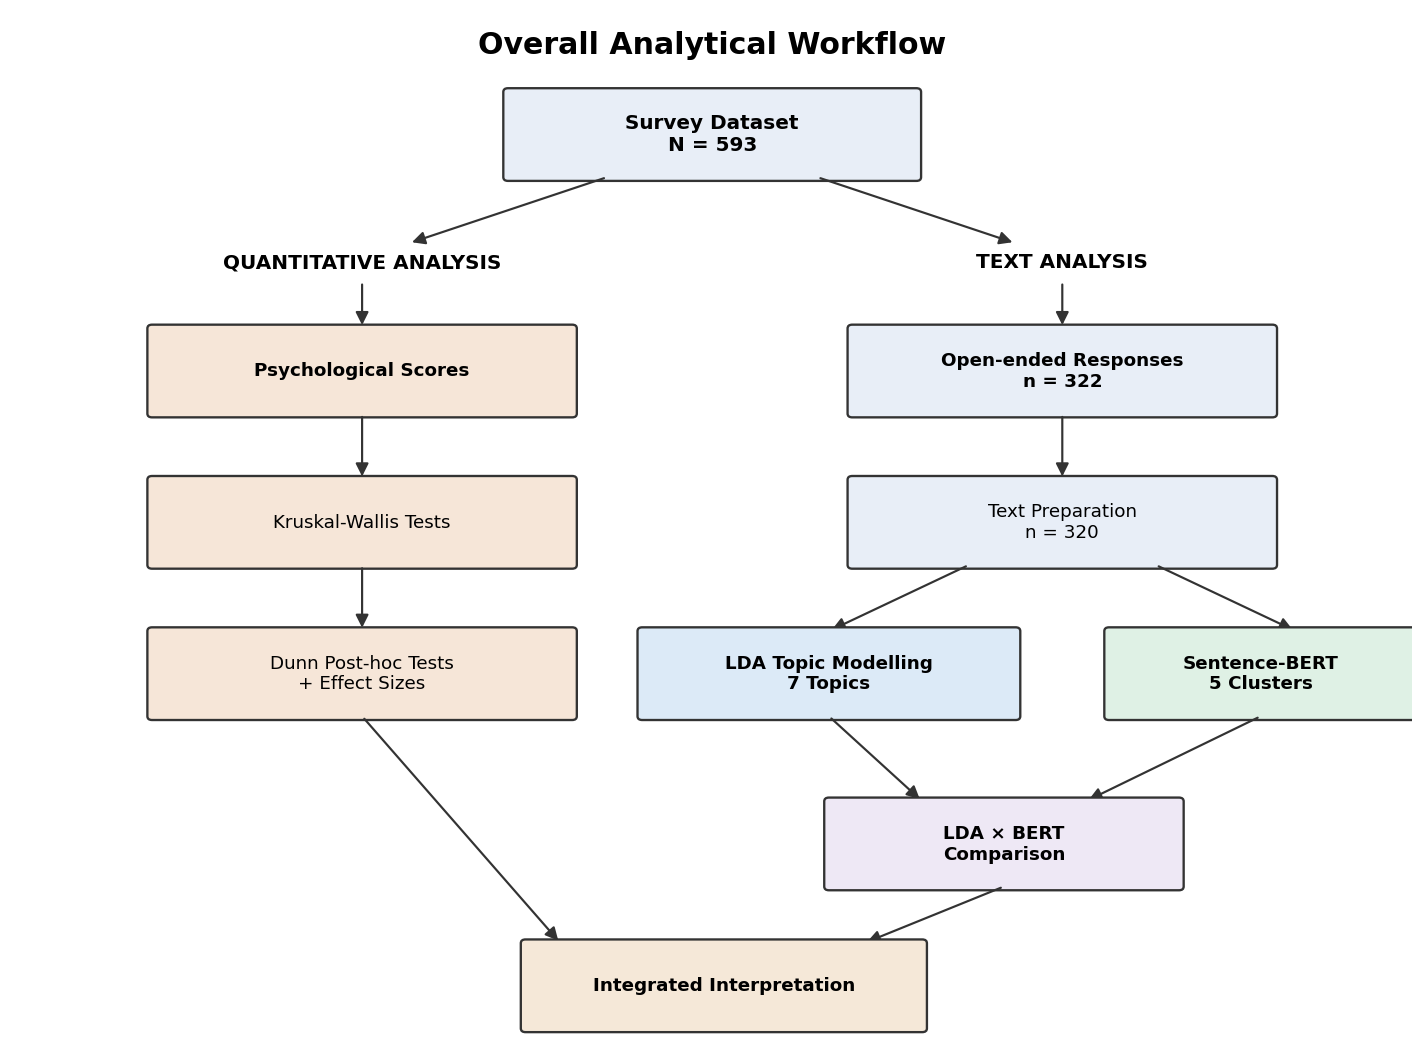

Saved as:
Figure_Overall_Analytical_Workflow_Clear.png


In [177]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ============================================================
# OVERALL ANALYTICAL WORKFLOW — CLEAN VERSION
# ============================================================

fig, ax = plt.subplots(figsize=(12, 9))

ax.set_xlim(0, 12)
ax.set_ylim(0, 11)
ax.axis("off")

# ------------------------------------------------------------
# Colour palette
# ------------------------------------------------------------

EDGE = "#333333"

INPUT = "#E8EEF7"       # light blue-grey
QUANT = "#F6E6D8"       # light beige
LDA = "#DCEAF7"         # light blue
BERT = "#DFF1E5"        # light green
COMPARE = "#EEE8F5"     # light purple
FINAL = "#F5E8D8"       # light cream


# ------------------------------------------------------------
# Functions
# ------------------------------------------------------------

def add_box(ax, x, y, w, h, text, colour,
            fontsize=11, bold=False):

    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.04",
        linewidth=1.4,
        edgecolor=EDGE,
        facecolor=colour
    )

    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal"
    )


def add_arrow(ax, x1, y1, x2, y2):

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.3,
        color=EDGE
    )

    ax.add_patch(arrow)


# ============================================================
# TITLE
# ============================================================

ax.text(
    6,
    10.65,
    "Overall Analytical Workflow",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)


# ============================================================
# SURVEY DATASET
# ============================================================

add_box(
    ax,
    4.25, 9.25, 3.5, 0.9,
    "Survey Dataset\nN = 593",
    INPUT,
    fontsize=12,
    bold=True
)


# ============================================================
# BRANCH HEADINGS
# ============================================================

ax.text(
    3.0,
    8.35,
    "QUANTITATIVE ANALYSIS",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

ax.text(
    9.0,
    8.35,
    "TEXT ANALYSIS",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)


# ============================================================
# ARROWS FROM DATASET TO BRANCH HEADINGS
# ============================================================

add_arrow(
    ax,
    5.1, 9.25,
    3.4, 8.55
)

add_arrow(
    ax,
    6.9, 9.25,
    8.6, 8.55
)


# ============================================================
# QUANTITATIVE ANALYSIS BRANCH
# ============================================================

add_arrow(
    ax,
    3.0, 8.15,
    3.0, 7.65
)

add_box(
    ax,
    1.2, 6.75, 3.6, 0.9,
    "Psychological Scores",
    QUANT,
    fontsize=11,
    bold=True
)

add_arrow(
    ax,
    3.0, 6.75,
    3.0, 6.05
)

add_box(
    ax,
    1.2, 5.15, 3.6, 0.9,
    "Kruskal-Wallis Tests",
    QUANT,
    fontsize=11
)

add_arrow(
    ax,
    3.0, 5.15,
    3.0, 4.45
)

add_box(
    ax,
    1.2, 3.55, 3.6, 0.9,
    "Dunn Post-hoc Tests\n+ Effect Sizes",
    QUANT,
    fontsize=11
)


# ============================================================
# TEXT ANALYSIS BRANCH
# ============================================================

add_arrow(
    ax,
    9.0, 8.15,
    9.0, 7.65
)

add_box(
    ax,
    7.2, 6.75, 3.6, 0.9,
    "Open-ended Responses\nn = 322",
    INPUT,
    fontsize=11,
    bold=True
)

add_arrow(
    ax,
    9.0, 6.75,
    9.0, 6.05
)

add_box(
    ax,
    7.2, 5.15, 3.6, 0.9,
    "Text Preparation\nn = 320",
    INPUT,
    fontsize=11
)


# ============================================================
# SPLIT TEXT ANALYSIS INTO LDA + BERT
# ============================================================

add_arrow(
    ax,
    8.2, 5.15,
    7.0, 4.45
)

add_arrow(
    ax,
    9.8, 5.15,
    11.0, 4.45
)


# ============================================================
# LDA
# ============================================================

add_box(
    ax,
    5.4, 3.55, 3.2, 0.9,
    "LDA Topic Modelling\n7 Topics",
    LDA,
    fontsize=11,
    bold=True
)


# ============================================================
# SENTENCE-BERT
# ============================================================

add_box(
    ax,
    9.4, 3.55, 2.6, 0.9,
    "Sentence-BERT\n5 Clusters",
    BERT,
    fontsize=11,
    bold=True
)


# ============================================================
# LDA × BERT COMPARISON
# ============================================================

add_arrow(
    ax,
    7.0, 3.55,
    7.8, 2.65
)

add_arrow(
    ax,
    10.7, 3.55,
    9.2, 2.65
)

add_box(
    ax,
    7.0, 1.75, 3.0, 0.9,
    "LDA × BERT\nComparison",
    COMPARE,
    fontsize=11,
    bold=True
)


# ============================================================
# INTEGRATED INTERPRETATION
# ============================================================

add_arrow(
    ax,
    3.0, 3.55,
    4.7, 1.15
)

add_arrow(
    ax,
    8.5, 1.75,
    7.3, 1.15
)

add_box(
    ax,
    4.4, 0.25, 3.4, 0.9,
    "Integrated Interpretation",
    FINAL,
    fontsize=11,
    bold=True
)


# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    "Figure_Overall_Analytical_Workflow_Clear.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved as:")
print("Figure_Overall_Analytical_Workflow_Clear.png")

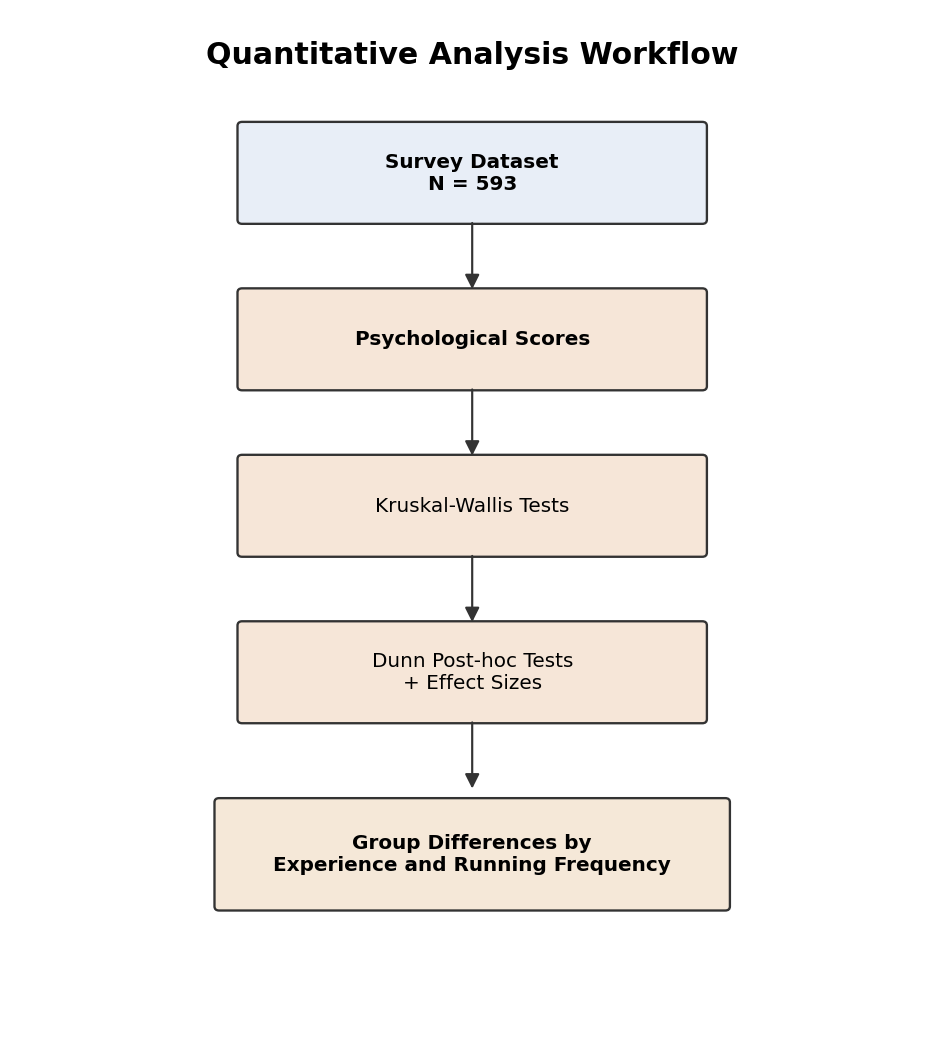

In [180]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

EDGE = "#333333"
DATA = "#E8EEF7"
QUANT = "#F6E6D8"
FINAL = "#F5E8D8"

def box(ax, x, y, w, h, text, colour, bold=False, fontsize=12):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04",
        linewidth=1.4,
        edgecolor=EDGE,
        facecolor=colour
    )
    ax.add_patch(patch)

    ax.text(
        x + w/2, y + h/2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal"
    )

def arrow(ax, x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=1.3,
            color=EDGE
        )
    )

fig, ax = plt.subplots(figsize=(8, 9))
ax.set_xlim(0, 8)
ax.set_ylim(0, 10)
ax.axis("off")

ax.text(
    4, 9.5,
    "Quantitative Analysis Workflow",
    ha="center",
    fontsize=18,
    fontweight="bold"
)

box(
    ax, 2, 8.0, 4, 0.9,
    "Survey Dataset\nN = 593",
    DATA,
    bold=True
)

arrow(ax, 4, 8.0, 4, 7.3)

box(
    ax, 2, 6.4, 4, 0.9,
    "Psychological Scores",
    QUANT,
    bold=True
)

arrow(ax, 4, 6.4, 4, 5.7)

box(
    ax, 2, 4.8, 4, 0.9,
    "Kruskal-Wallis Tests",
    QUANT
)

arrow(ax, 4, 4.8, 4, 4.1)

box(
    ax, 2, 3.2, 4, 0.9,
    "Dunn Post-hoc Tests\n+ Effect Sizes",
    QUANT
)

arrow(ax, 4, 3.2, 4, 2.5)

box(
    ax, 1.8, 1.4, 4.4, 1.0,
    "Group Differences by\nExperience and Running Frequency",
    FINAL,
    bold=True
)

plt.tight_layout()

plt.savefig(
    "Figure_Quantitative_Workflow.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

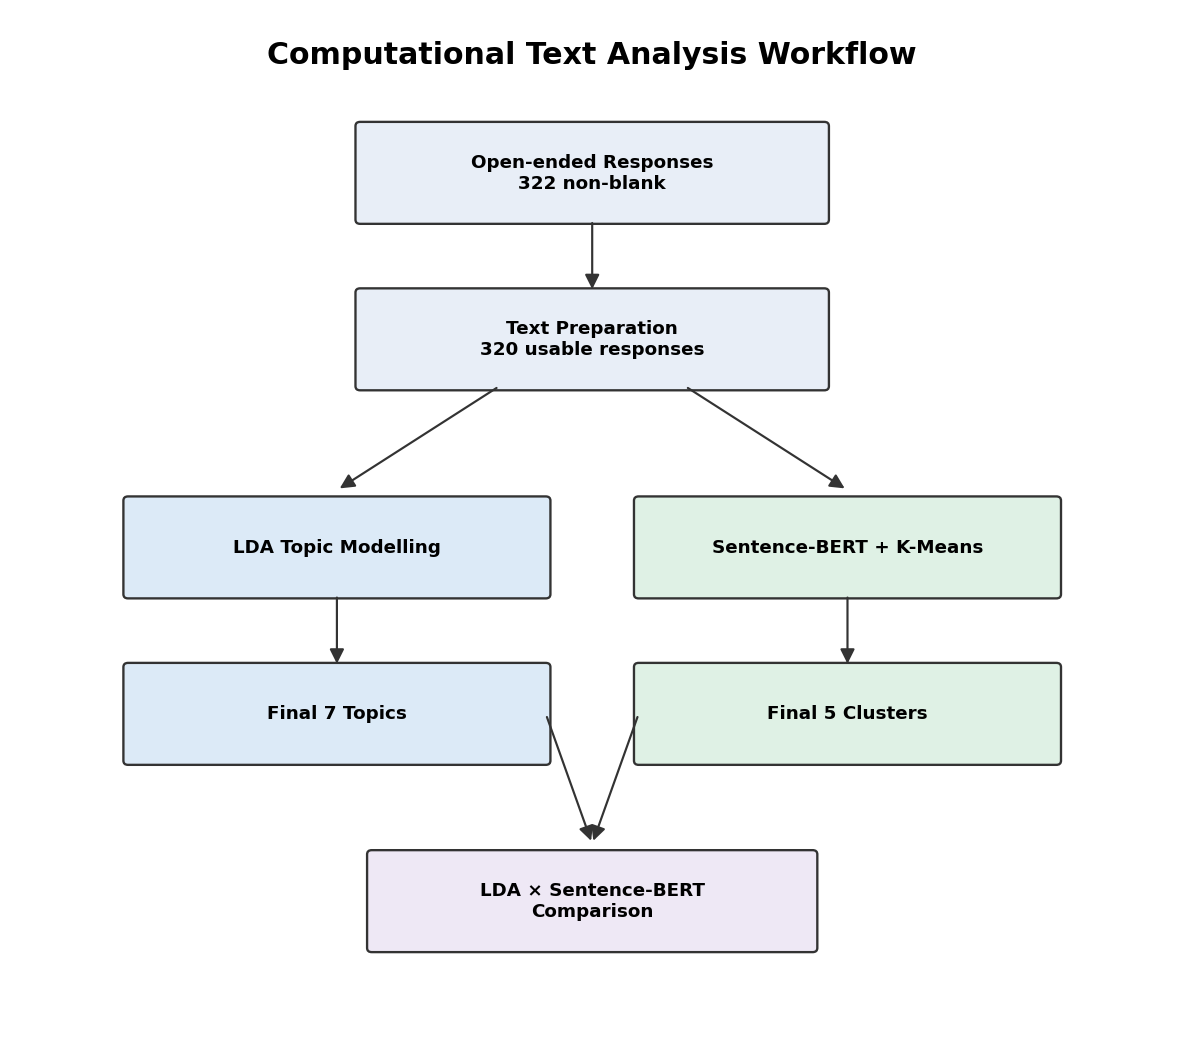

In [182]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

EDGE = "#333333"
DATA = "#E8EEF7"
LDA = "#DCEAF7"
BERT = "#DFF1E5"
COMPARE = "#EEE8F5"

def box(ax, x, y, w, h, text, colour, bold=False, fontsize=11):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04",
        linewidth=1.4,
        edgecolor=EDGE,
        facecolor=colour
    )
    ax.add_patch(patch)

    ax.text(
        x + w/2, y + h/2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal"
    )

def arrow(ax, x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=1.3,
            color=EDGE
        )
    )

fig, ax = plt.subplots(figsize=(10, 9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

ax.text(
    5, 9.5,
    "Computational Text Analysis Workflow",
    ha="center",
    fontsize=18,
    fontweight="bold"
)

box(
    ax, 3, 8.0, 4, 0.9,
    "Open-ended Responses\n322 non-blank",
    DATA,
    bold=True
)

arrow(ax, 5, 8.0, 5, 7.3)

box(
    ax, 3, 6.4, 4, 0.9,
    "Text Preparation\n320 usable responses",
    DATA,
    bold=True
)

# split
arrow(ax, 4.2, 6.4, 2.8, 5.4)
arrow(ax, 5.8, 6.4, 7.2, 5.4)

# LDA
box(
    ax, 1.0, 4.4, 3.6, 0.9,
    "LDA Topic Modelling",
    LDA,
    bold=True
)

arrow(ax, 2.8, 4.4, 2.8, 3.7)

box(
    ax, 1.0, 2.8, 3.6, 0.9,
    "Final 7 Topics",
    LDA,
    bold=True
)

# BERT
box(
    ax, 5.4, 4.4, 3.6, 0.9,
    "Sentence-BERT + K-Means",
    BERT,
    bold=True
)

arrow(ax, 7.2, 4.4, 7.2, 3.7)

box(
    ax, 5.4, 2.8, 3.6, 0.9,
    "Final 5 Clusters",
    BERT,
    bold=True
)

# merge
arrow(ax, 4.6, 3.25, 5.0, 2.0)
arrow(ax, 5.4, 3.25, 5.0, 2.0)

box(
    ax, 3.1, 1.0, 3.8, 0.9,
    "LDA × Sentence-BERT\nComparison",
    COMPARE,
    bold=True
)

plt.tight_layout()

plt.savefig(
    "Figure_NLP_Workflow.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()